# Leaf Species Classification Using Machine Learning
## CST 8506 Final Project

**Team Members:**
- Hye Ran Yoo
- Peng Wang
- Yinyuan Chen

**Dataset:** Leaf (UCI Machine Learning Repository)

**Date:** March 27, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from PIL import Image

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print("All libraries loaded successfully.")

PyTorch version: 2.10.0+cu128
Device: cuda
All libraries loaded successfully.


In [2]:
# Mount Google Drive and set up project directory
from google.colab import drive
drive.mount('/content/drive')

# Define project directory on Google Drive
PROJECT_DIR = '/content/drive/MyDrive/CST8506_FinalProject'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f'Project directory: {PROJECT_DIR}')


Mounted at /content/drive
Project directory: /content/drive/MyDrive/CST8506_FinalProject


In [3]:
# Download Leaf dataset from UCI Repository to Google Drive
import zipfile
import urllib.request

DATA_DIR = os.path.join(PROJECT_DIR, 'dataset')
os.makedirs(DATA_DIR, exist_ok=True)

# UCI Leaf dataset URL
DATASET_URL = 'https://archive.ics.uci.edu/static/public/288/leaf.zip'
ZIP_PATH = os.path.join(DATA_DIR, 'leaf.zip')

# Download if not already present
CSV_PATH = os.path.join(DATA_DIR, 'leaf.csv')
if not os.path.exists(CSV_PATH):
    print('Downloading Leaf dataset from UCI...')
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print('Dataset downloaded and extracted successfully.')
else:
    print('Dataset already exists on Google Drive.')

# Set paths for image directories
BW_DIR = os.path.join(DATA_DIR, 'BW')
RGB_DIR = os.path.join(DATA_DIR, 'RGB')

print(f'DATA_DIR: {DATA_DIR}')
print(f'CSV_PATH: {CSV_PATH}')
print(f'BW_DIR: {BW_DIR}')
print(f'RGB_DIR: {RGB_DIR}')


Dataset already exists on Google Drive.
DATA_DIR: /content/drive/MyDrive/CST8506_FinalProject/dataset
CSV_PATH: /content/drive/MyDrive/CST8506_FinalProject/dataset/leaf.csv
BW_DIR: /content/drive/MyDrive/CST8506_FinalProject/dataset/BW
RGB_DIR: /content/drive/MyDrive/CST8506_FinalProject/dataset/RGB


---
# 1. Introduction (Hye Ran Yoo)

Plant species identification is essential in botany, ecology, agriculture, and environmental conservation. Traditional leaf classification by manual inspection is time-consuming and prone to subjective errors. Machine learning and computer vision techniques offer a practical, automated alternative.

This project applies data mining and machine learning methods to the **Leaf dataset** from the UCI Machine Learning Repository (Silva & Marçal, 2013). The dataset contains **340 leaf specimens** from **30 plant species**, each described by **14 numerical features** extracted from digital images. Both a tabular feature dataset and an image dataset (RGB colour and binary scanned images) are available.

The project follows the **CRISP-DM** framework, covering Business Understanding, Data Understanding, Data Preparation, Modelling, Evaluation, and Deployment. Part 1 focuses on the first three phases.

Three core tasks are addressed:
- **Classification** (Hye Ran Yoo)
- **Clustering** (Peng Wang)
- **Outlier Detection** (Yinyuan Chen)

Each team member is responsible for preparing the data for their respective task, since different tasks may benefit from different attribute selections and preparation strategies.

---
# 2. Business Understanding (Hye Ran Yoo)

## 2.1 Determine Business Objectives

The primary objective is to develop a reliable system for automatic plant species recognition based on leaf characteristics. Accurate species identification supports biodiversity monitoring, ecological surveys, agricultural quality control, and educational applications.

The goal is to evaluate how well different machine learning techniques can distinguish between 30 plant species using both numerical leaf features and raw leaf images, and to compare traditional approaches on feature data against deep learning methods on image data.

## 2.2 Assess Situation

The Leaf dataset is publicly available from the UCI Machine Learning Repository under CC BY 4.0. Key considerations:
- The dataset is relatively small (340 instances across 30 classes), with class sizes ranging from 8 to 16 specimens per species, creating a slight class imbalance.
- The image dataset contains 443 RGB images across 40 species and 340 binary images across 30 species. The RGB folder has 10 additional species not present in the feature dataset.
- Available tools: Python, scikit-learn, PyTorch (for CNN), Power BI or Tableau (for visualization).

## 2.3 Determine Data Mining Goals

- **Classification:** Build models (Naïve Bayes, SVM, MLP, Stacking, CNN) to predict species labels from features or images.
- **Clustering:** Apply unsupervised methods (kMeans, DBSCAN, EM) to find natural groupings and compare them to known species.
- **Outlier Detection:** Use anomaly detection (LOF, Isolation Forest, One-Class SVM) to identify specimens that deviate from typical patterns.

Success metrics: accuracy, precision, recall, and F1-score for classification; cluster validity indices for clustering; expert review of flagged outliers for anomaly detection.

## 2.4 Produce Project Plan

**Workload Distribution:**

| Task | Subtask | Student Name |
|---|---|---|
| Introduction |  | Hye Ran Yoo |
| Business Understanding |  | Hye Ran Yoo |
| Data Understanding | Collect Initial Data, Describe Data | Peng Wang |
| Data Understanding | Explore Data, Verify Data Quality | Yinyuan Chen |
| Preparation, classification, evaluation and discussion of results of both image and feature dataset |  | Peng Wang |
| Preparation, clustering, evaluation and discussion of results of both image and feature dataset |  | Hye Ran Yoo |
| Preparation, outlier detection, evaluation and discussion of results of both image and feature dataset |  | Yinyuan Chen |
| Discussion of results |  | All members |
| Conclusion |  | All members |

**Timeline:**

| Phase | Activities | Deadline |
|---|---|---|
| Part 1 | Business Understanding, Data Understanding, Data Preparation | March 27, 2026 |
| Part 2 – Modelling | Build and evaluate models for all three tasks | March 28 – April 1, 2026 |
| Report Finalization | Discussion, conclusion, final report | April 2, 2026 |
| Presentation | Prepare and deliver presentation | April 8, 2026 |

---
# 3. Data Understanding

## 3.1 Collect Initial Data (Peng Wang)

The Leaf dataset was obtained from the UCI Machine Learning Repository:
- Source: https://archive.ics.uci.edu/dataset/288/leaf
- Citation: Silva, P. & Marçal, A. (2013). Leaf [Dataset]. UCI Machine Learning Repository.

The dataset consists of:
1. **Feature dataset** (`leaf.csv`): 340 instances, 16 columns
2. **Image dataset**: RGB images (40 species) and BW images (30 species)

In [4]:
# Paths are defined in the Google Drive setup cell above

# Load feature dataset
column_names = [
    'Class', 'Specimen_Number', 'Eccentricity', 'Aspect_Ratio',
    'Elongation', 'Solidity', 'Stochastic_Convexity', 'Isoperimetric_Factor',
    'Max_Indentation_Depth', 'Lobedness', 'Avg_Intensity', 'Avg_Contrast',
    'Smoothness', 'Third_Moment', 'Uniformity', 'Entropy'
]

df = pd.read_csv(CSV_PATH, header=None, names=column_names)
print(f"Feature dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Feature dataset loaded: 340 rows, 16 columns


,Class,Specimen_Number,Eccentricity,Aspect_Ratio,Elongation,Solidity,Stochastic_Convexity,Isoperimetric_Factor,Max_Indentation_Depth,Lobedness,Avg_Intensity,Avg_Contrast,Smoothness,Third_Moment,Uniformity,Entropy
0,1,1,0.72694,1.4742,0.32396,0.98535,1.00000,0.83592,0.004657,0.003947,0.047790,0.127950,0.016108,0.005232,0.000275,1.17560
1,1,2,0.74173,1.5257,0.36116,0.98152,0.99825,0.79867,0.005242,0.005002,0.024160,0.090476,0.008119,0.002708,0.000075,0.69659
2,1,3,0.76722,1.5725,0.38998,0.97755,1.00000,0.80812,0.007457,0.010121,0.011897,0.057445,0.003289,0.000921,0.000038,0.44348
3,1,4,0.73797,1.4597,0.35376,0.97566,1.00000,0.81697,0.006877,0.008607,0.015950,0.065491,0.004271,0.001154,0.000066,0.58785
4,1,5,0.82301,1.7707,0.44462,0.97698,1.00000,0.75493,0.007428,0.010042,0.007938,0.045339,0.002051,0.000560,0.000024,0.34214


## 3.2 Describe Data (Peng Wang)

The 16 columns in the feature dataset are:

| Column | Attribute | Type | Description |
|---|---|---|---|
| 1 | Class (Species) | Integer | Species label (30 unique values) |
| 2 | Specimen Number | Integer | Specimen index within each species |
| 3 | Eccentricity | Real | Distance between focal points / major axis length |
| 4 | Aspect Ratio | Real | Major axis / minor axis of bounding ellipse |
| 5 | Elongation | Real | How elongated the leaf shape is |
| 6 | Solidity | Real | Leaf area / convex hull area |
| 7 | Stochastic Convexity | Real | Probabilistic convexity measure |
| 8 | Isoperimetric Factor | Real | Perimeter-to-area ratio |
| 9 | Max Indentation Depth | Real | Deepest indentation on leaf margin |
| 10 | Lobedness | Real | Degree of lobedness |
| 11 | Average Intensity | Real | Mean pixel intensity |
| 12 | Average Contrast | Real | Texture contrast measure |
| 13 | Smoothness | Real | Texture smoothness |
| 14 | Third Moment | Real | Skewness indicator of intensity distribution |
| 15 | Uniformity | Real | Uniformity of intensity distribution |
| 16 | Entropy | Real | Entropy of intensity distribution |

In [5]:
# Descriptive statistics
feature_cols = column_names[2:]  # 14 numerical features

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
print(f"Number of features: {len(feature_cols)}")
print(f"Total instances: {df.shape[0]}")
print(f"Number of species: {df['Class'].nunique()}")
print()
df[feature_cols].describe().round(4)

DESCRIPTIVE STATISTICS
Number of features: 14
Total instances: 340
Number of species: 30



,Eccentricity,Aspect_Ratio,Elongation,Solidity,Stochastic_Convexity,Isoperimetric_Factor,Max_Indentation_Depth,Lobedness,Avg_Intensity,Avg_Contrast,Smoothness,Third_Moment,Uniformity,Entropy
count,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000,340.0000
mean,0.7199,2.4402,0.5138,0.9042,0.9438,0.5312,0.0373,0.5238,0.0513,0.1245,0.0177,0.0059,0.0004,1.1626
std,0.2083,2.5990,0.1956,0.1146,0.1150,0.2175,0.0386,1.0396,0.0360,0.0519,0.0138,0.0053,0.0004,0.5849
min,0.1171,1.0066,0.1076,0.4855,0.3965,0.0784,0.0028,0.0015,0.0050,0.0334,0.0011,0.0002,0.0000,0.1694
25%,0.5506,1.2113,0.3496,0.8907,0.9662,0.3468,0.0095,0.0165,0.0228,0.0834,0.0069,0.0021,0.0001,0.7189
50%,0.7634,1.5707,0.5019,0.9481,0.9930,0.5792,0.0239,0.1036,0.0421,0.1194,0.0140,0.0044,0.0002,1.0774
75%,0.8951,2.3431,0.6334,0.9769,1.0000,0.7007,0.0478,0.4164,0.0730,0.1638,0.0261,0.0083,0.0005,1.5546
max,0.9987,19.0380,0.9483,0.9939,1.0000,0.8582,0.1990,7.2062,0.1907,0.2808,0.0731,0.0298,0.0029,2.7085


In [6]:
# Class distribution
class_dist = df['Class'].value_counts().sort_index()
print(f"Classes: {len(class_dist)}, Min per class: {class_dist.min()}, Max per class: {class_dist.max()}")
print(f"Class labels: {sorted(df['Class'].unique())}")
print()

# Non-consecutive labels
missing_labels = [l for l in range(1, 37) if l not in df['Class'].unique()]
print(f"Missing class labels: {missing_labels}")
print("These correspond to species only in the RGB folder, not in the feature dataset.")
print()
print(class_dist.to_frame('Count'))

Classes: 30, Min per class: 8, Max per class: 16
Class labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]

Missing class labels: [16, 17, 18, 19, 20, 21]
These correspond to species only in the RGB folder, not in the feature dataset.

       Count
Class       
1         12
2         10
3         10
4          8
5         12
6          8
7         10
8         11
9         14
10        13
11        16
12        12
13        13
14        12
15        10
22        12
23        11
24        13
25         9
26        12
27        11
28        12
29        12
30        12
31        11
32        11
33        11
34        11
35    

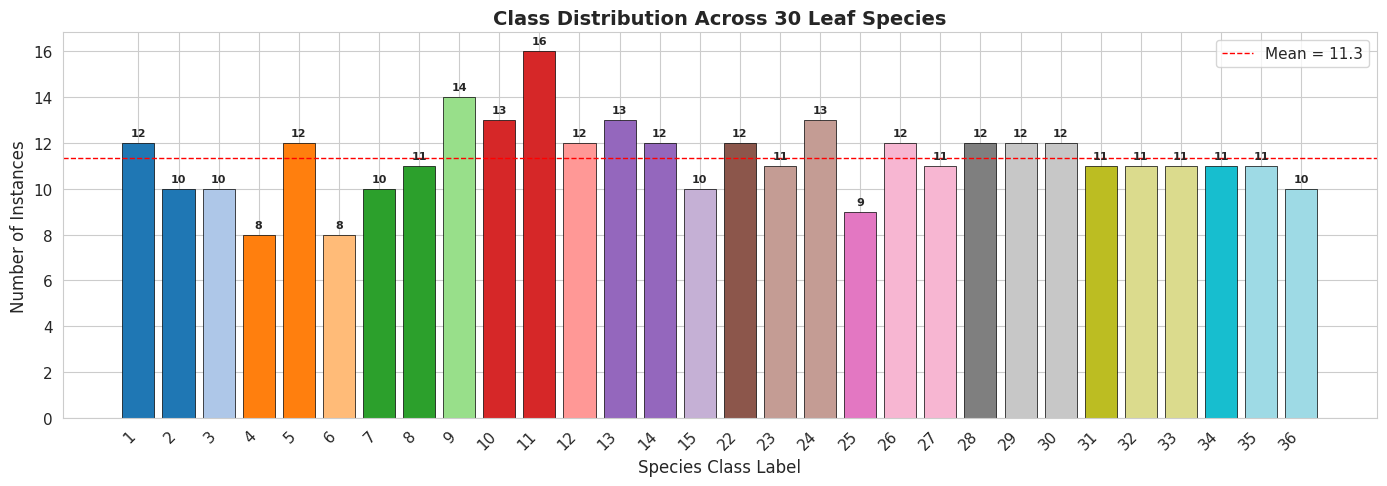

In [7]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab20(np.linspace(0, 1, len(class_dist)))
bars = ax.bar(class_dist.index.astype(str), class_dist.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Species Class Label', fontsize=12)
ax.set_ylabel('Number of Instances', fontsize=12)
ax.set_title('Class Distribution Across 30 Leaf Species', fontsize=14, fontweight='bold')
ax.axhline(y=class_dist.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean = {class_dist.mean():.1f}')
ax.legend()
for bar, count in zip(bars, class_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(count),
            ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# Image dataset summary
bw_species = sorted([d for d in os.listdir(BW_DIR) if os.path.isdir(os.path.join(BW_DIR, d))])
rgb_species = sorted([d for d in os.listdir(RGB_DIR) if os.path.isdir(os.path.join(RGB_DIR, d))])

bw_total = sum(len(os.listdir(os.path.join(BW_DIR, sp))) for sp in bw_species)
rgb_total = sum(len(os.listdir(os.path.join(RGB_DIR, sp))) for sp in rgb_species)

# Sample image properties
sample_bw = Image.open(os.path.join(BW_DIR, bw_species[0], os.listdir(os.path.join(BW_DIR, bw_species[0]))[0]))
sample_rgb = Image.open(os.path.join(RGB_DIR, rgb_species[0], os.listdir(os.path.join(RGB_DIR, rgb_species[0]))[0]))

print("=" * 60)
print("IMAGE DATASET SUMMARY")
print("=" * 60)
summary = pd.DataFrame({
    'Property': ['Total images', 'Species (folders)', 'Dimensions', 'Colour mode'],
    'RGB Images': [rgb_total, len(rgb_species), f'{sample_rgb.size[0]}x{sample_rgb.size[1]}', sample_rgb.mode],
    'BW Images': [bw_total, len(bw_species), f'{sample_bw.size[0]}x{sample_bw.size[1]}', 'Binary (1-bit)']
})
print(summary.to_string(index=False))

IMAGE DATASET SUMMARY
         Property RGB Images      BW Images
     Total images        443            340
Species (folders)         40             30
       Dimensions    720x960        720x960
      Colour mode        RGB Binary (1-bit)


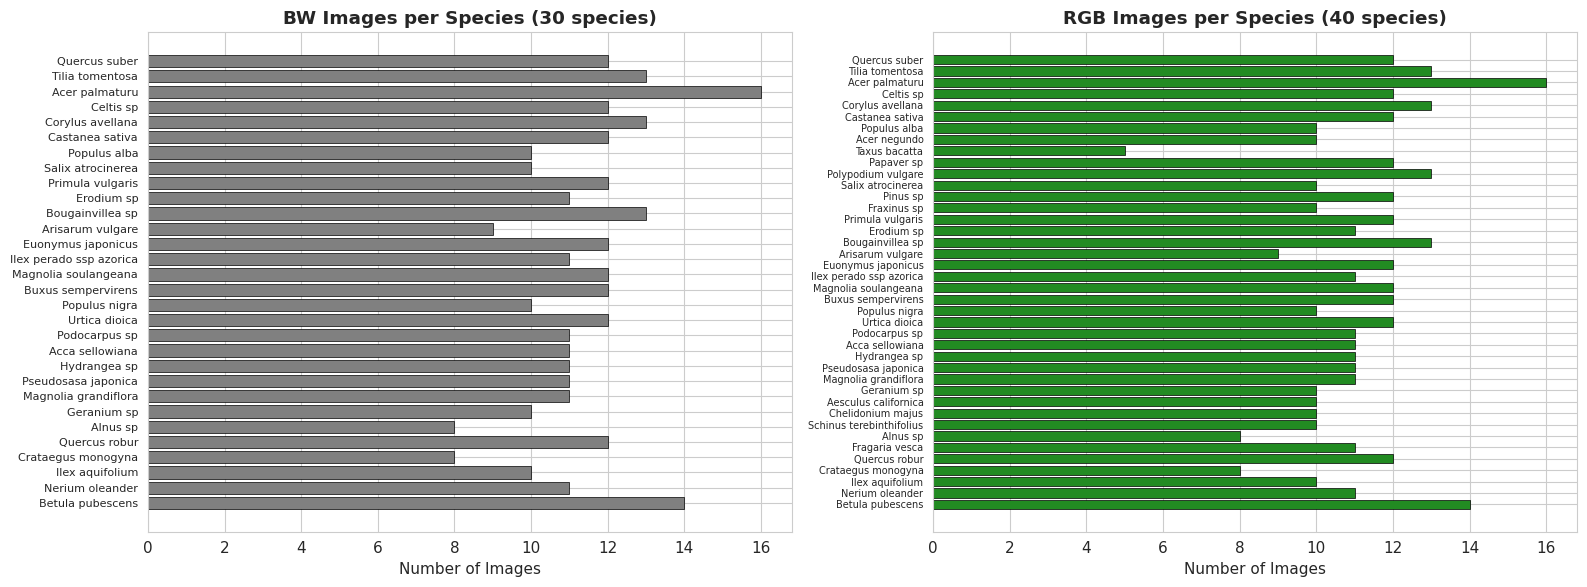

In [9]:
# Images per species
bw_counts = {sp: len(os.listdir(os.path.join(BW_DIR, sp))) for sp in bw_species}
rgb_counts = {sp: len(os.listdir(os.path.join(RGB_DIR, sp))) for sp in rgb_species}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bw_labels = [s.split('. ')[1] if '. ' in s else s for s in bw_counts.keys()]
axes[0].barh(bw_labels, list(bw_counts.values()), color='gray', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Number of Images')
axes[0].set_title('BW Images per Species (30 species)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)

rgb_labels = [s.split('. ')[1] if '. ' in s else s for s in rgb_counts.keys()]
axes[1].barh(rgb_labels, list(rgb_counts.values()), color='forestgreen', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Number of Images')
axes[1].set_title('RGB Images per Species (40 species)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

## 3.3 Explore Data (Yinyuan Chen)

Exploratory analysis is conducted on the 14 numerical features to examine distributions, correlations, and relationships.

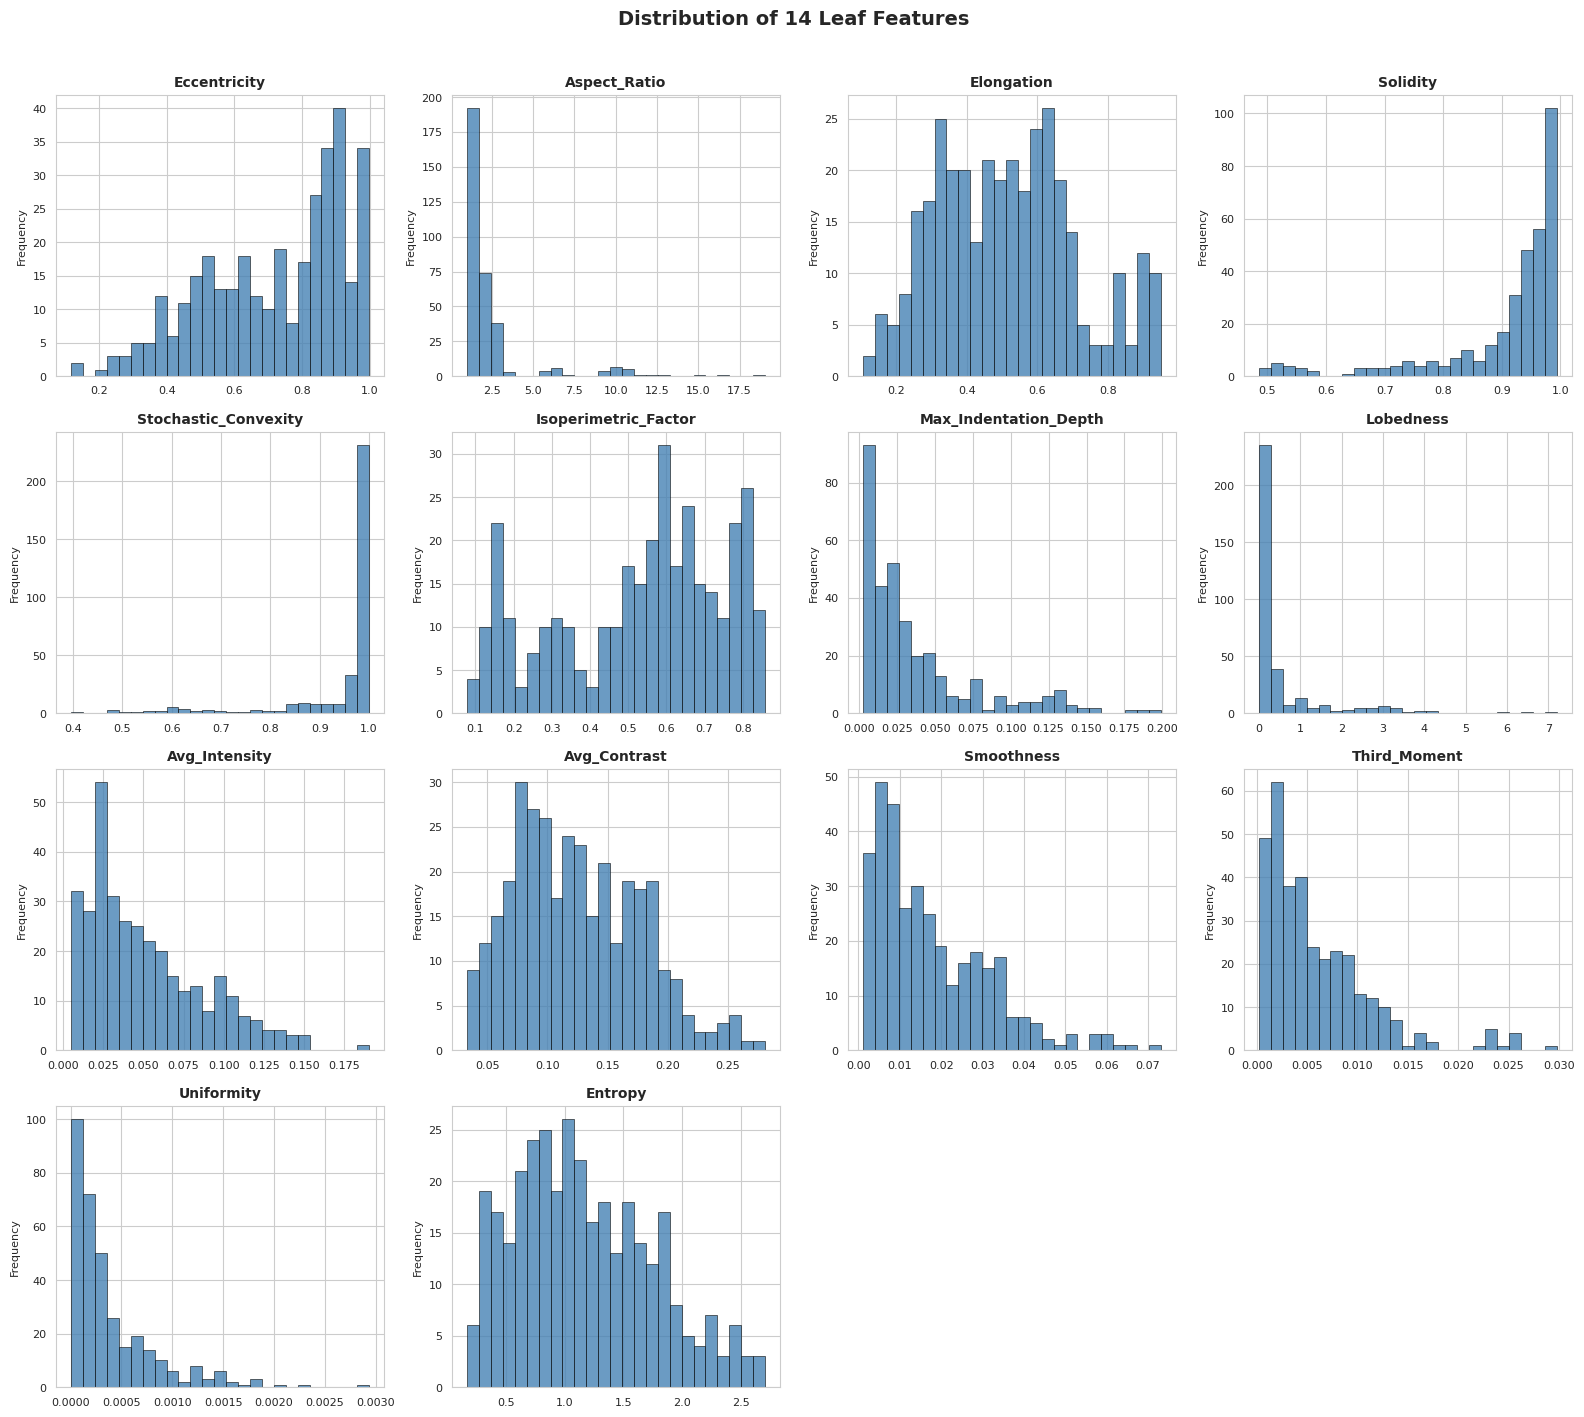

In [10]:
# Histograms of all 14 features
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black', linewidth=0.5, alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frequency', fontsize=8)
    axes[i].tick_params(labelsize=8)
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distribution of 14 Leaf Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

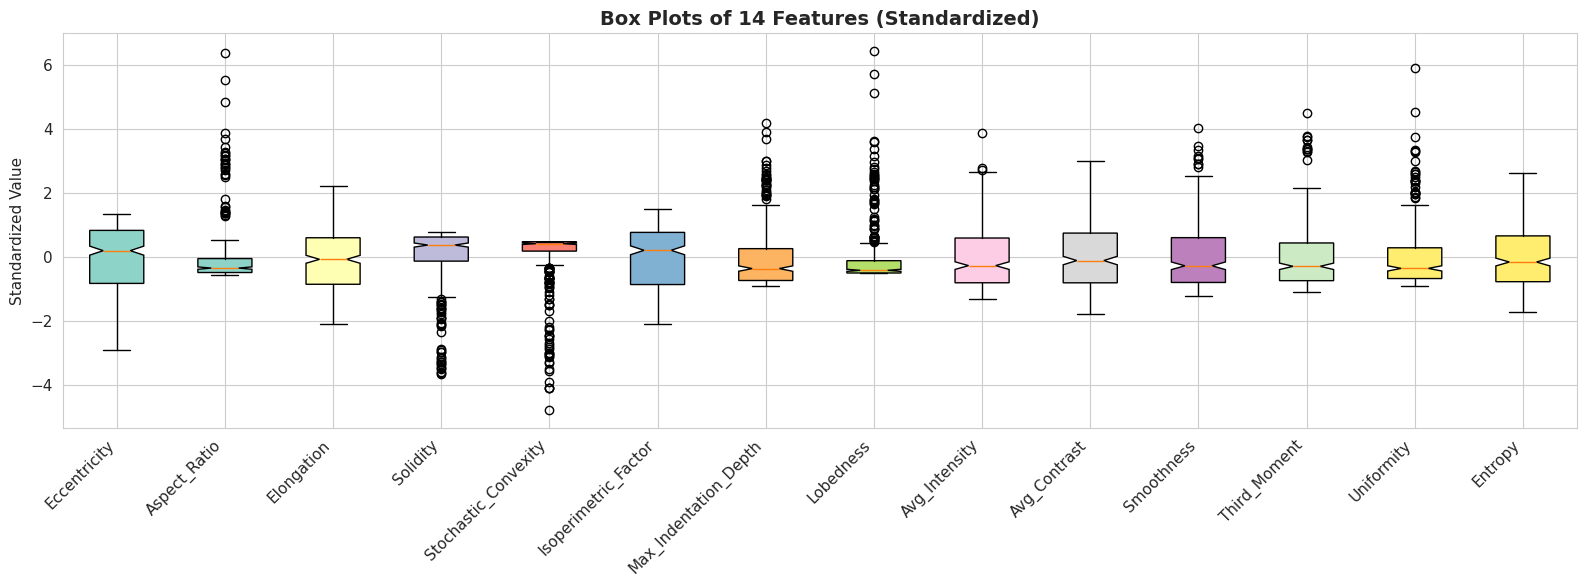

In [11]:
# Box plots (standardized for comparison)
scaler_temp = StandardScaler()
df_std_temp = pd.DataFrame(scaler_temp.fit_transform(df[feature_cols]), columns=feature_cols)

fig, ax = plt.subplots(figsize=(16, 6))
bp = ax.boxplot([df_std_temp[col] for col in feature_cols],
                labels=feature_cols, patch_artist=True, notch=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(feature_cols)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Box Plots of 14 Features (Standardized)', fontsize=14, fontweight='bold')
ax.set_ylabel('Standardized Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

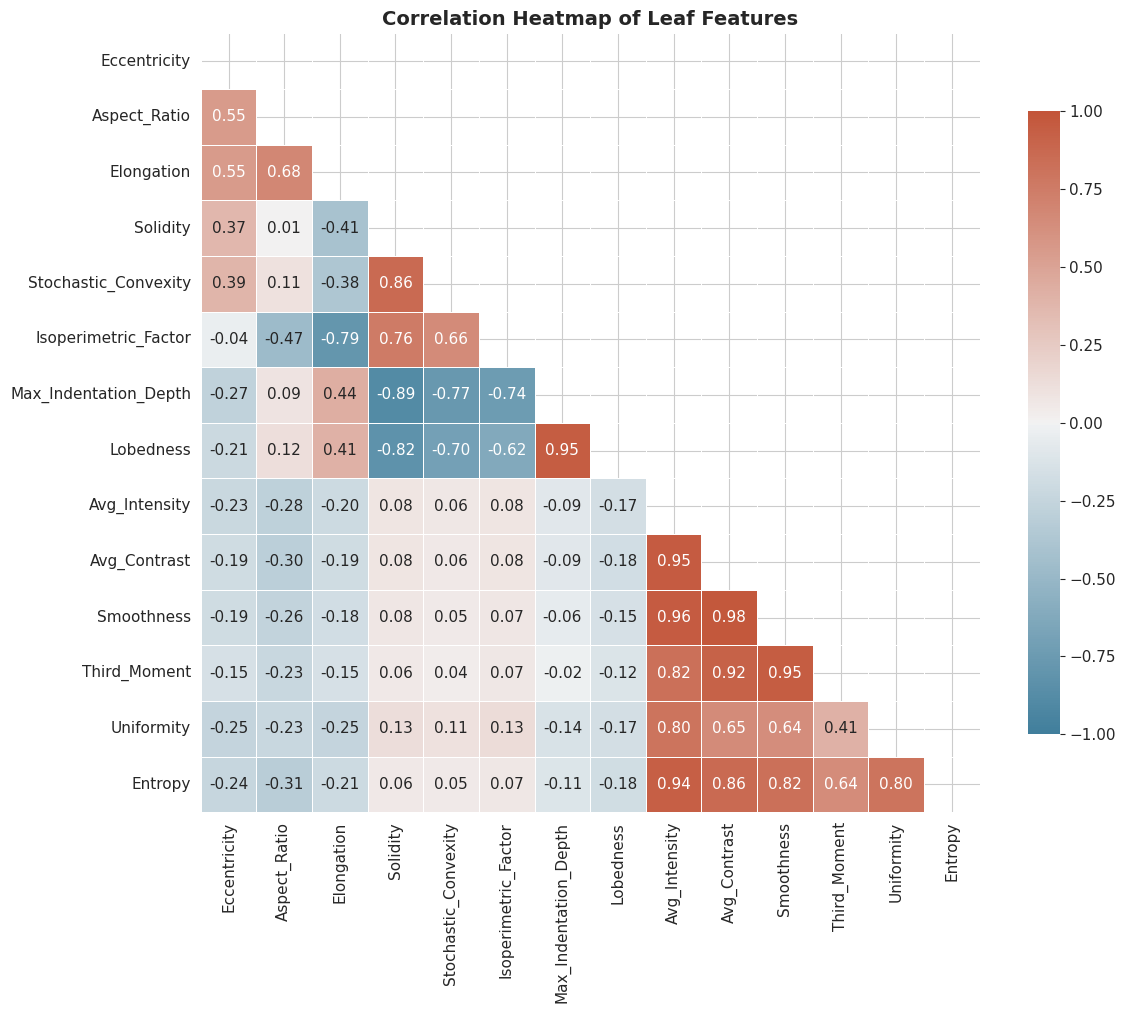

Notable correlations (|r| > 0.5):
  Eccentricity vs Aspect_Ratio: r = 0.551
  Eccentricity vs Elongation: r = 0.554
  Aspect_Ratio vs Elongation: r = 0.678
  Elongation vs Isoperimetric_Factor: r = -0.793
  Solidity vs Stochastic_Convexity: r = 0.863
  Solidity vs Isoperimetric_Factor: r = 0.755
  Solidity vs Max_Indentation_Depth: r = -0.886
  Solidity vs Lobedness: r = -0.824
  Stochastic_Convexity vs Isoperimetric_Factor: r = 0.656
  Stochastic_Convexity vs Max_Indentation_Depth: r = -0.769
  Stochastic_Convexity vs Lobedness: r = -0.700
  Isoperimetric_Factor vs Max_Indentation_Depth: r = -0.736
  Isoperimetric_Factor vs Lobedness: r = -0.624
  Max_Indentation_Depth vs Lobedness: r = 0.946
  Avg_Intensity vs Avg_Contrast: r = 0.955
  Avg_Intensity vs Smoothness: r = 0.955
  Avg_Intensity vs Third_Moment: r = 0.822
  Avg_Intensity vs Uniformity: r = 0.804
  Avg_Intensity vs Entropy: r = 0.936
  Avg_Contrast vs Smoothness: r = 0.980
  Avg_Contrast vs Third_Moment: r = 0.918
  Avg_Con

In [12]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap=sns.diverging_palette(230, 20, as_cmap=True),
            annot=True, fmt='.2f', square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of Leaf Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notable correlations (|r| > 0.5):")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {feature_cols[i]} vs {feature_cols[j]}: r = {r:.3f}")

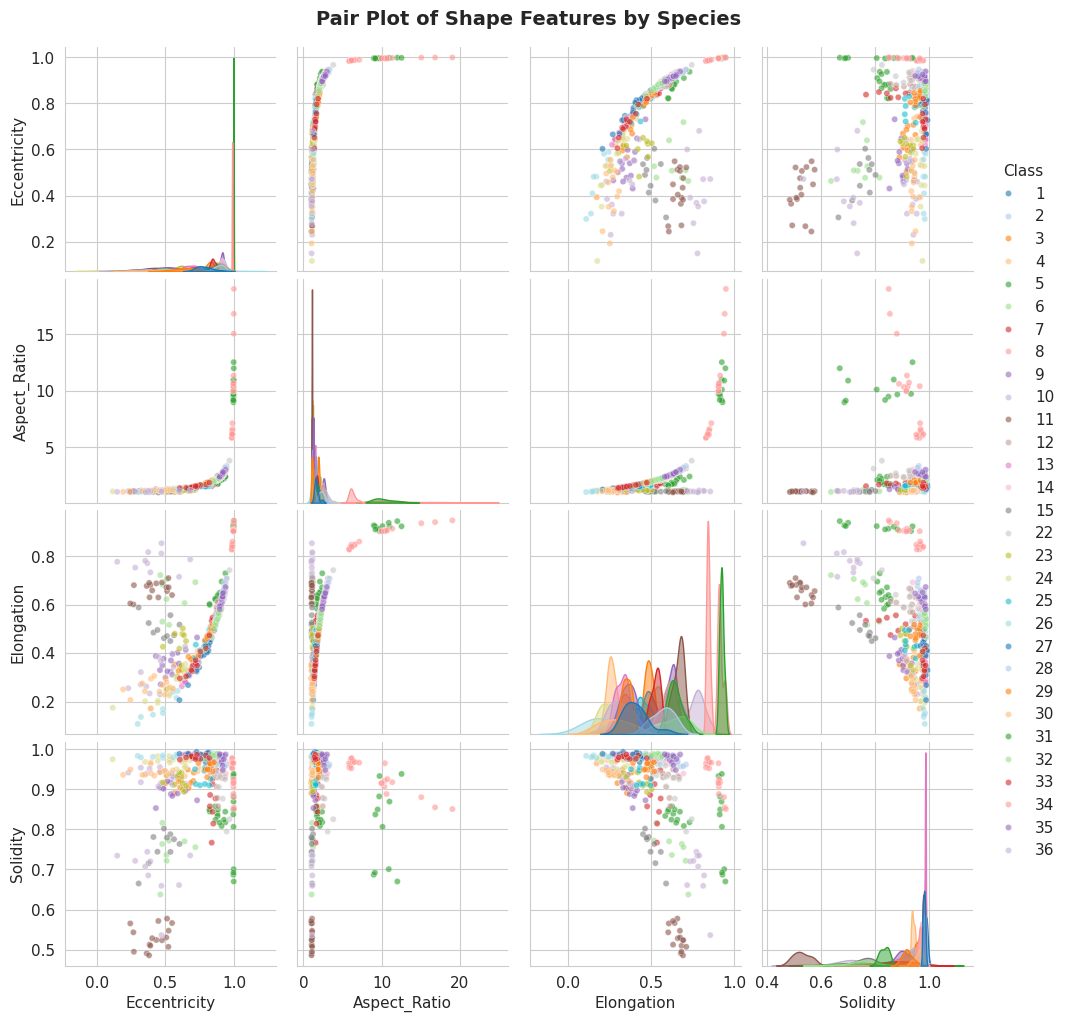

In [13]:
# Pair plot - shape features
shape_feats = ['Eccentricity', 'Aspect_Ratio', 'Elongation', 'Solidity']
df_plot = df[shape_feats + ['Class']].copy()
df_plot['Class'] = df_plot['Class'].astype(str)
g = sns.pairplot(df_plot, hue='Class', palette='tab20',
                 plot_kws={'s': 20, 'alpha': 0.6}, diag_kws={'alpha': 0.5}, height=2.5)
g.figure.suptitle('Pair Plot of Shape Features by Species', fontsize=14, fontweight='bold', y=1.02)
plt.show()

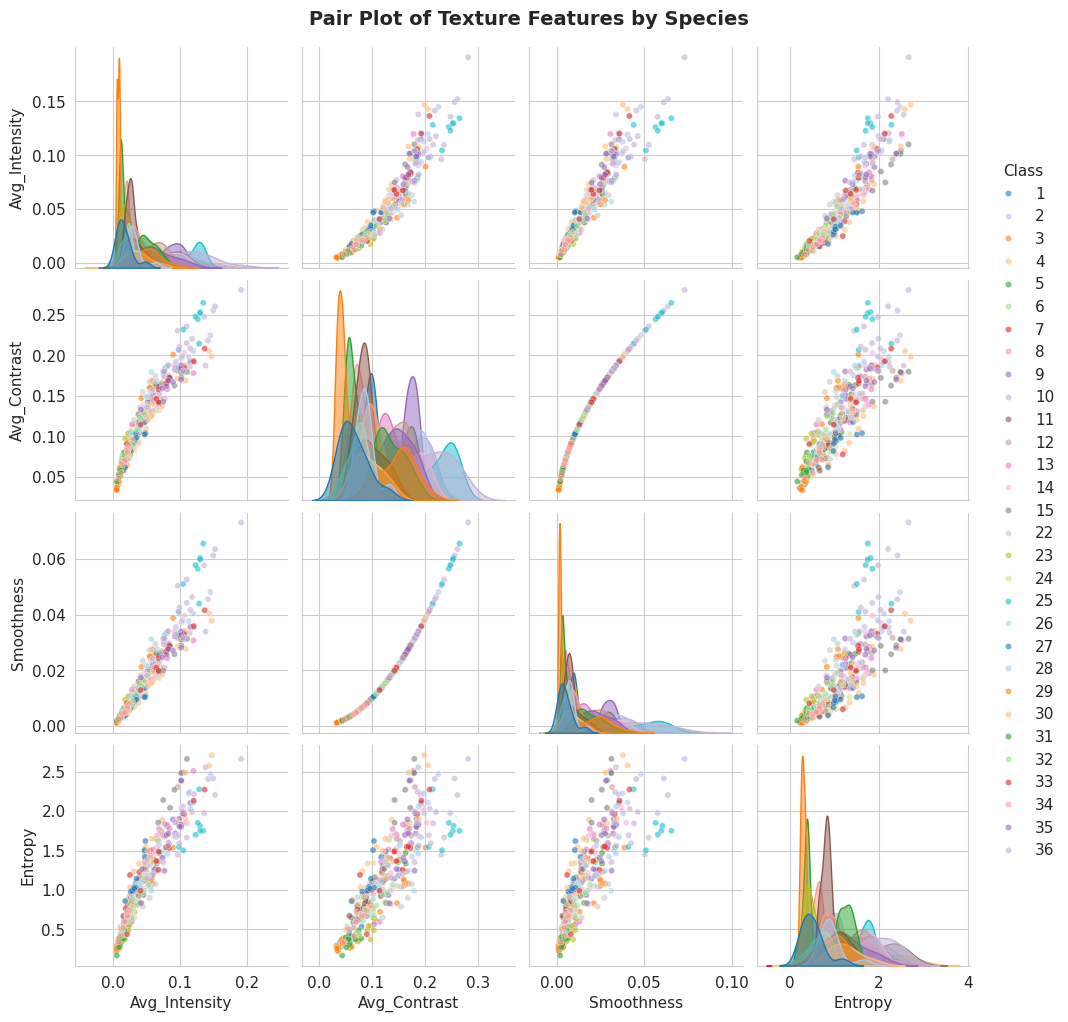

In [14]:
# Pair plot - texture features
texture_feats = ['Avg_Intensity', 'Avg_Contrast', 'Smoothness', 'Entropy']
df_plot2 = df[texture_feats + ['Class']].copy()
df_plot2['Class'] = df_plot2['Class'].astype(str)
g2 = sns.pairplot(df_plot2, hue='Class', palette='tab20',
                  plot_kws={'s': 20, 'alpha': 0.6}, diag_kws={'alpha': 0.5}, height=2.5)
g2.figure.suptitle('Pair Plot of Texture Features by Species', fontsize=14, fontweight='bold', y=1.02)
plt.show()

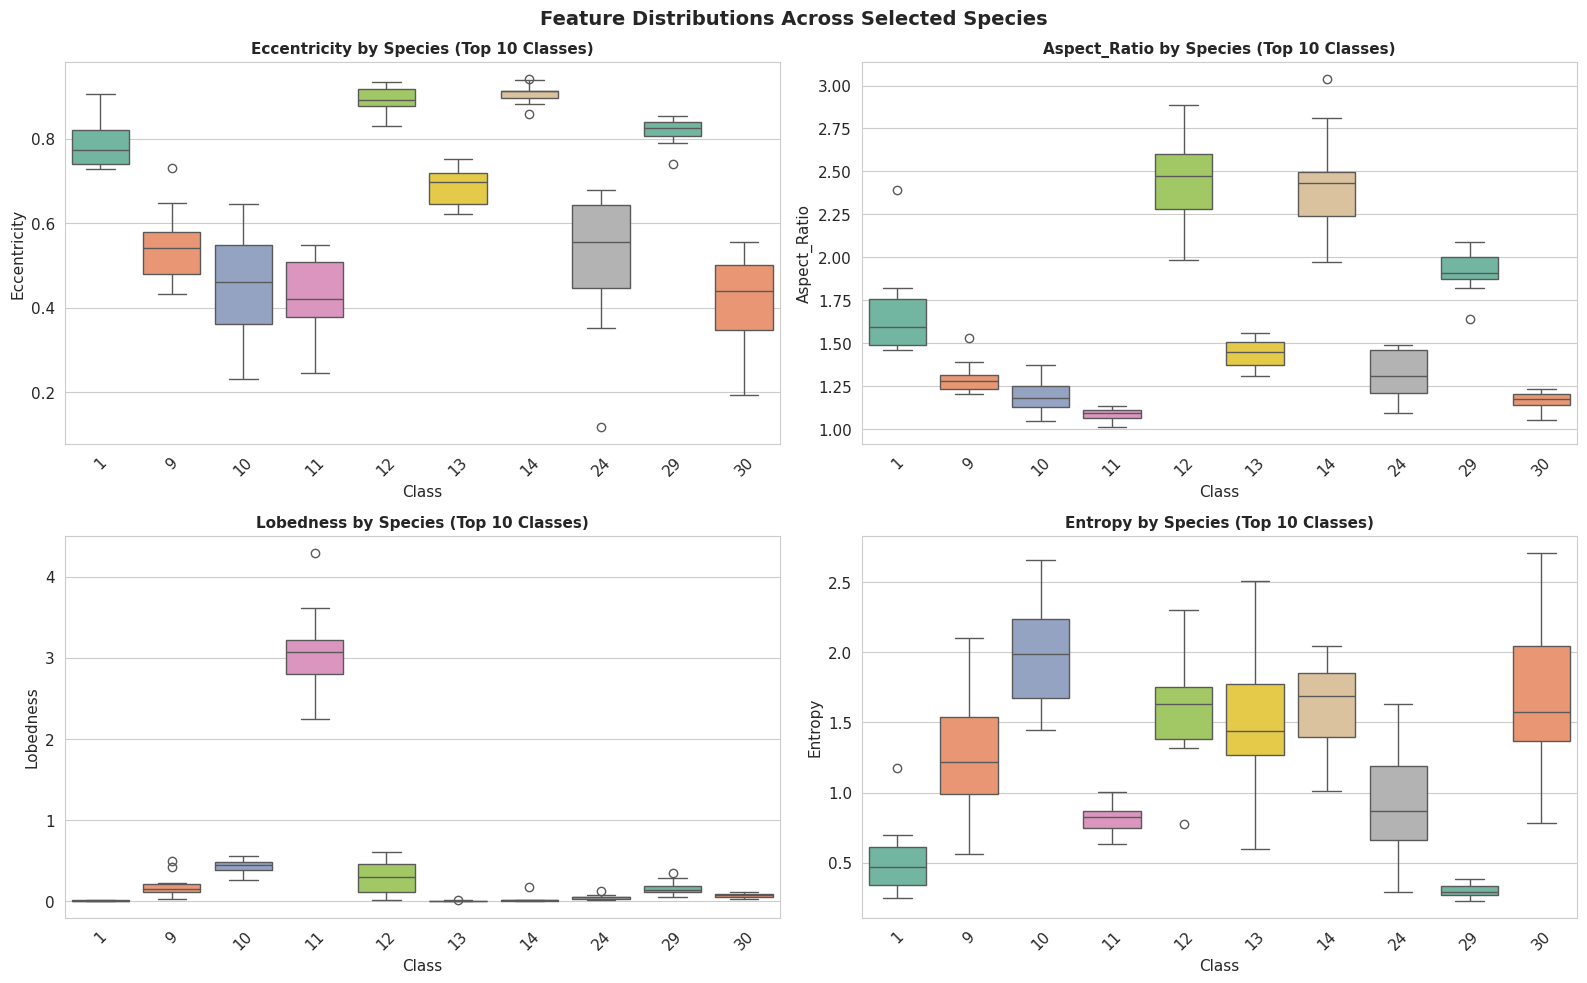

In [15]:
# Box plots by species for selected features
top_species = df['Class'].value_counts().nlargest(10).index
df_top = df[df['Class'].isin(top_species)].copy()
df_top['Class'] = df_top['Class'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(['Eccentricity', 'Aspect_Ratio', 'Lobedness', 'Entropy']):
    sns.boxplot(x='Class', y=col, data=df_top, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Species (Top 10 Classes)', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Feature Distributions Across Selected Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

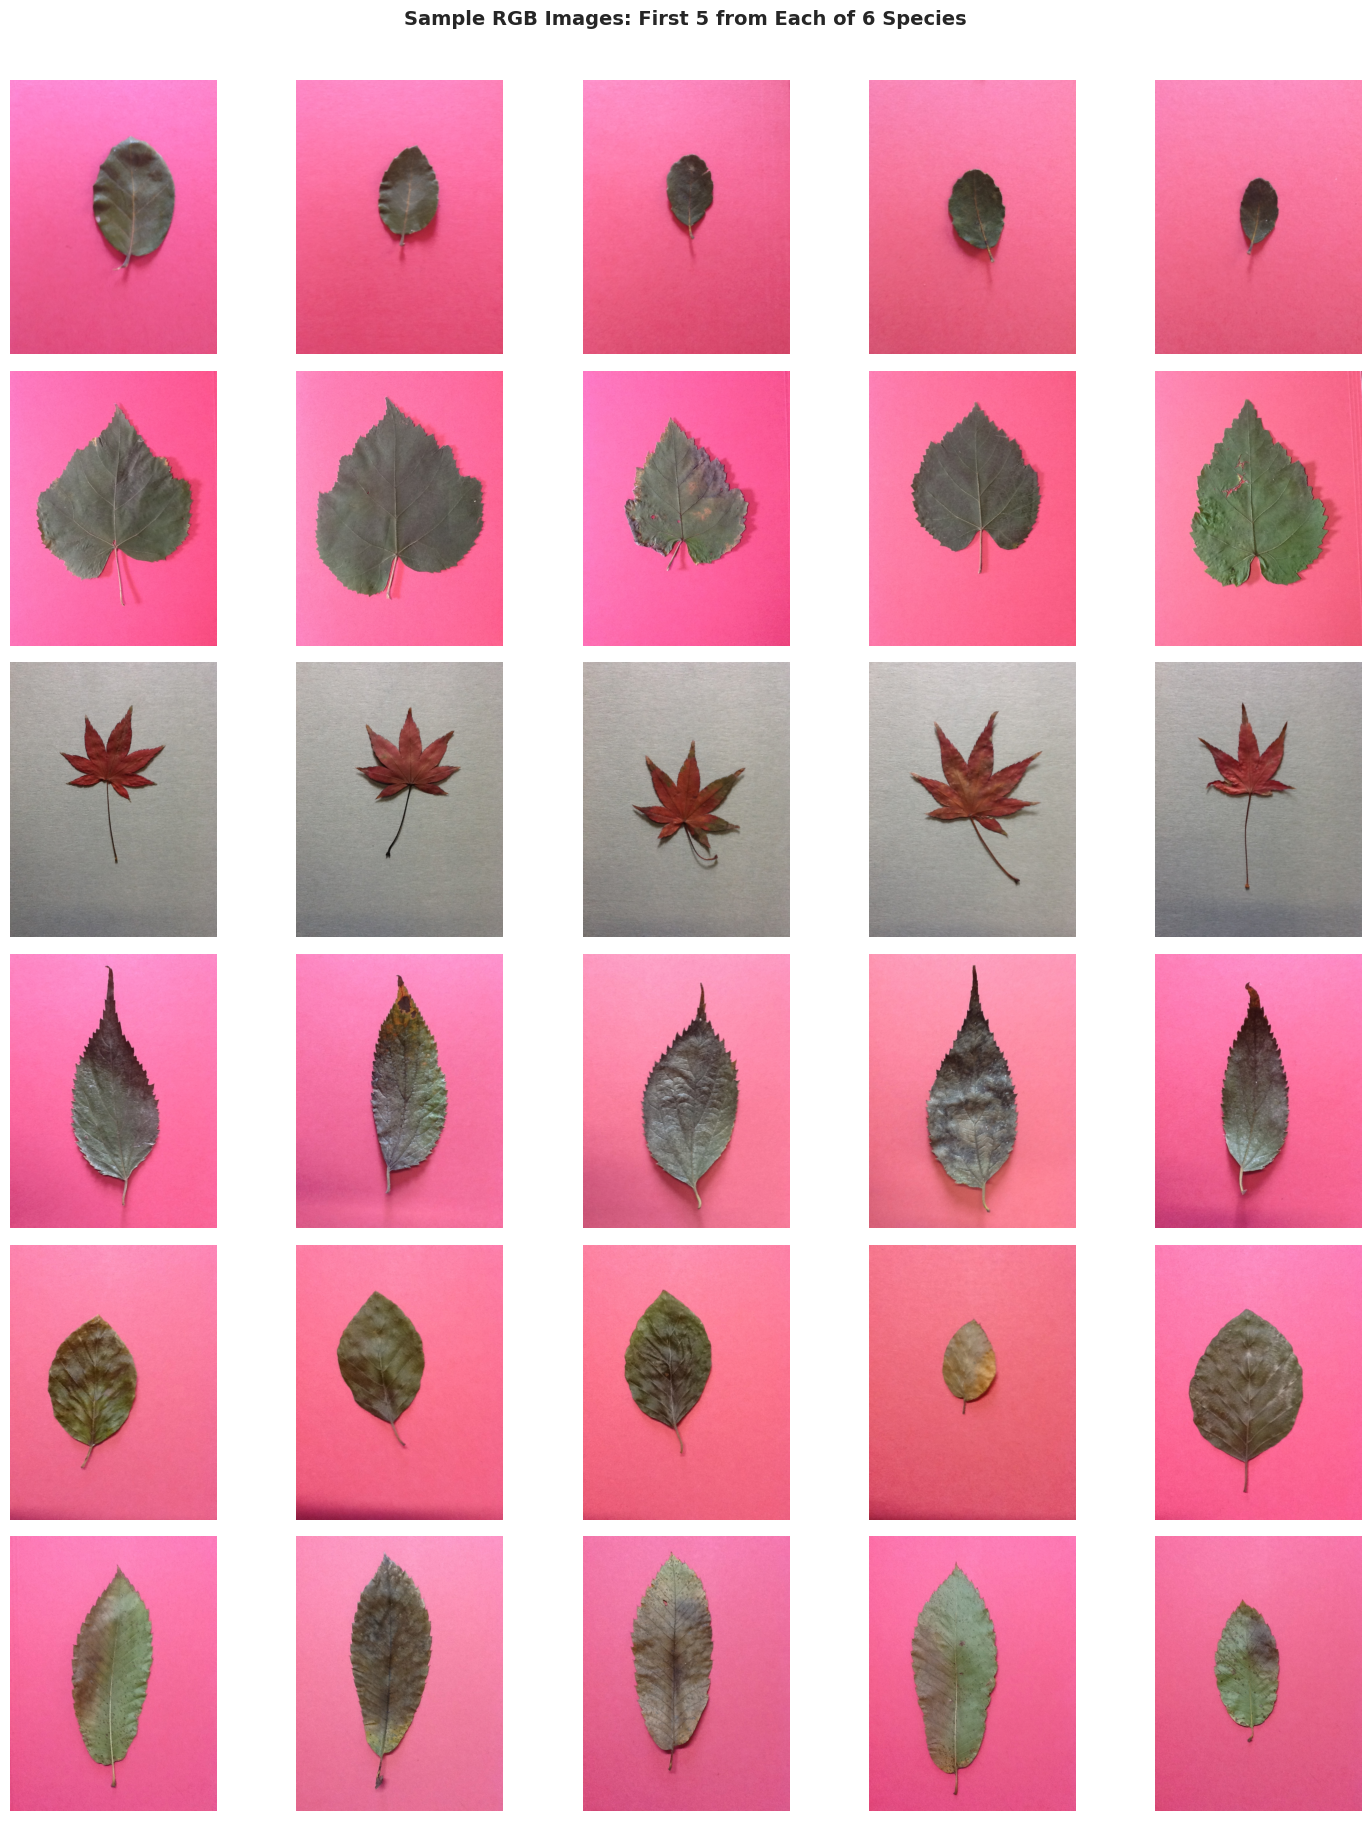

In [16]:
# Display sample RGB images: first 5 from each class, one class per row
sample_species_rgb = sorted(os.listdir(RGB_DIR))[:6]
fig, axes = plt.subplots(6, 5, figsize=(15, 18))
for row, sp_name in enumerate(sample_species_rgb):
    sp_path = os.path.join(RGB_DIR, sp_name)
    img_files = sorted(os.listdir(sp_path))[:5]
    for col, img_file in enumerate(img_files):
        img = Image.open(os.path.join(sp_path, img_file))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            label = sp_name.split('. ')[1] if '. ' in sp_name else sp_name
            axes[row, col].set_ylabel(label, fontsize=9, fontweight='bold', rotation=0, labelpad=80)
fig.suptitle('Sample RGB Images: First 5 from Each of 6 Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

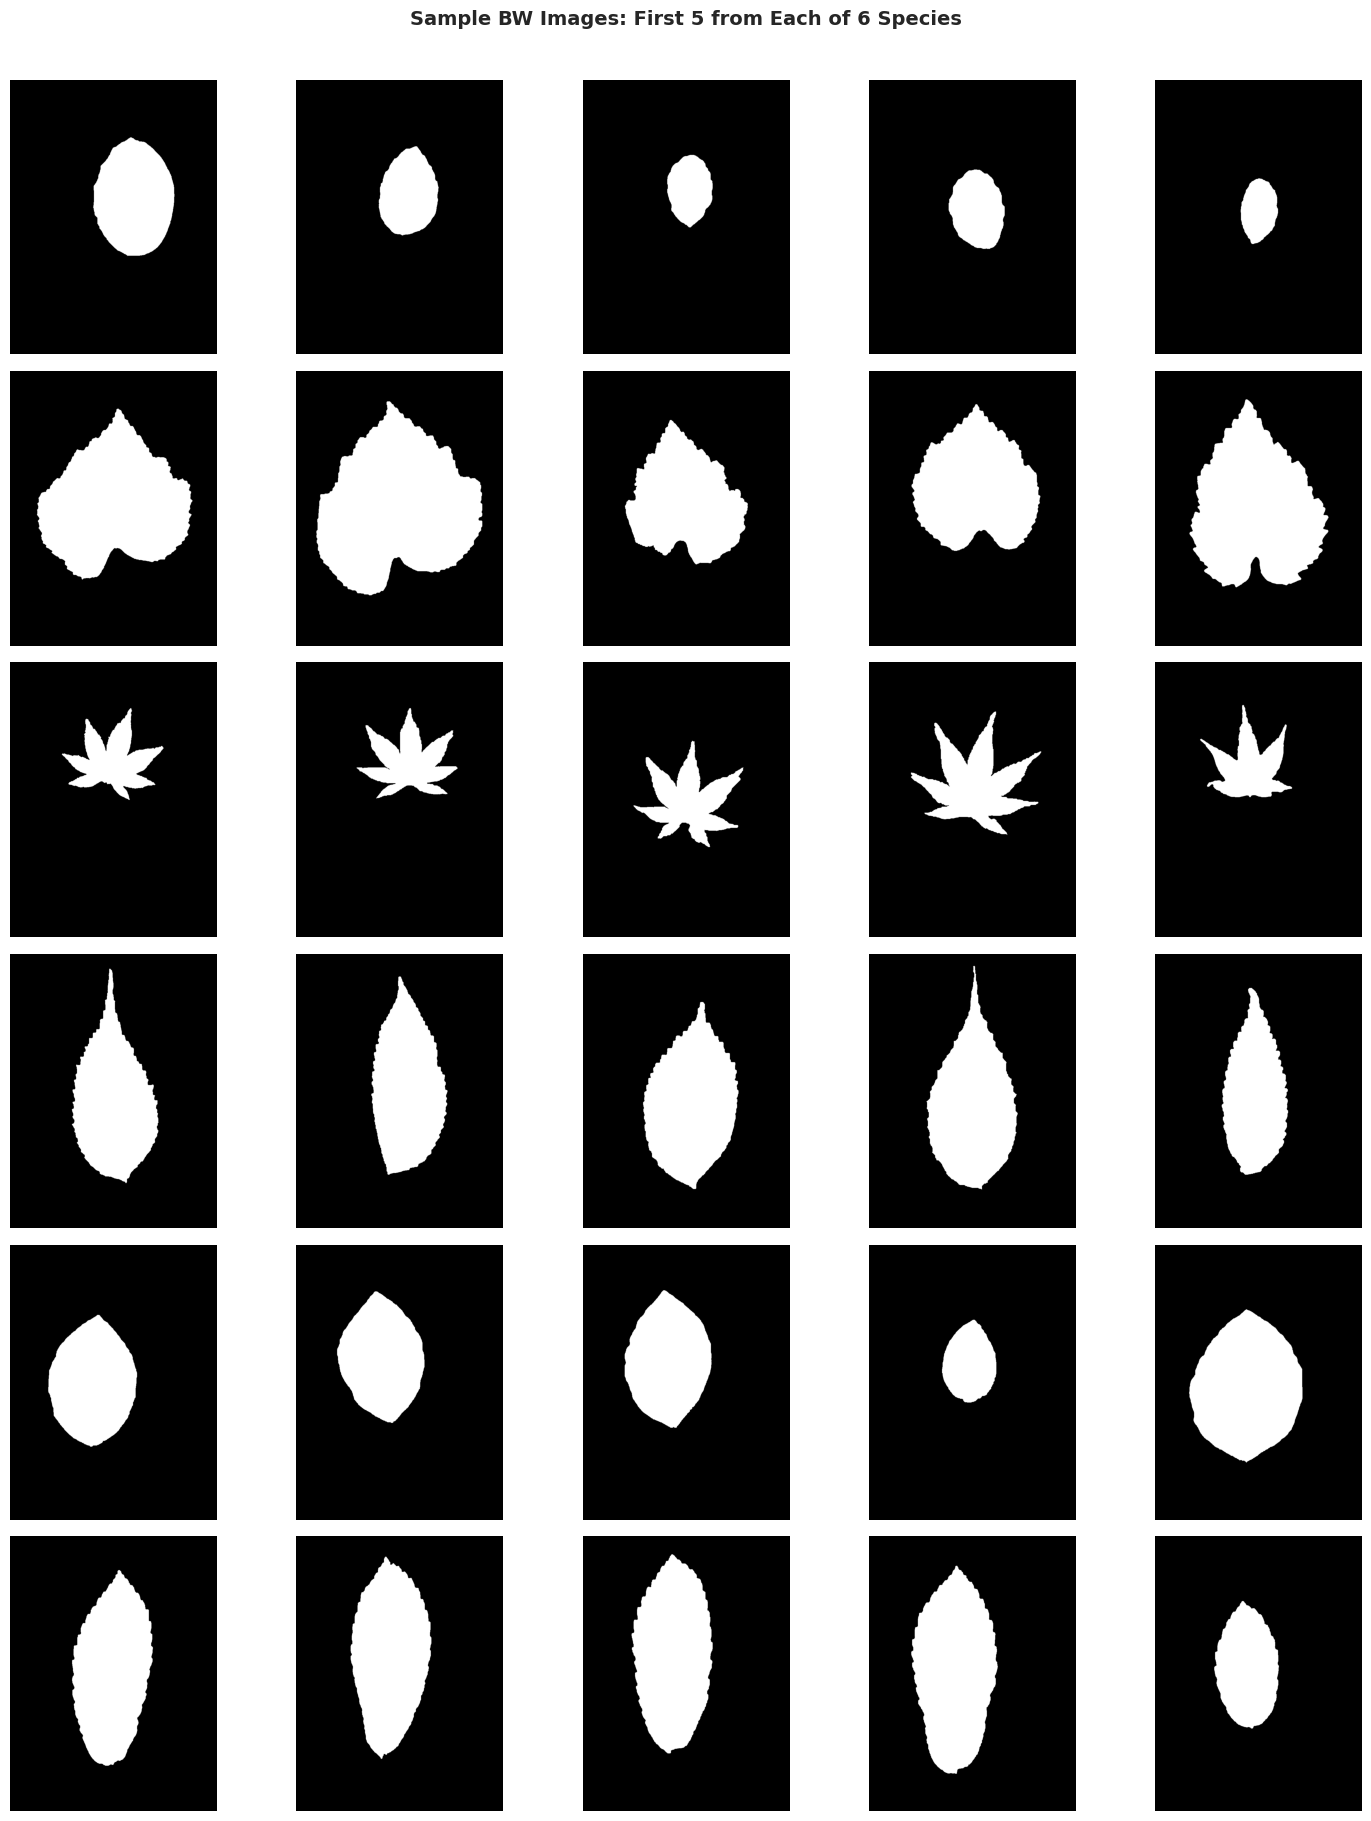

In [17]:
# Display sample BW images: first 5 from each class, one class per row
sample_species_bw = sorted(os.listdir(BW_DIR))[:6]
fig, axes = plt.subplots(6, 5, figsize=(15, 18))
for row, sp_name in enumerate(sample_species_bw):
    sp_path = os.path.join(BW_DIR, sp_name)
    img_files = sorted(os.listdir(sp_path))[:5]
    for col, img_file in enumerate(img_files):
        img = Image.open(os.path.join(sp_path, img_file))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            label = sp_name.split('. ')[1] if '. ' in sp_name else sp_name
            axes[row, col].set_ylabel(label, fontsize=9, fontweight='bold', rotation=0, labelpad=80)
fig.suptitle('Sample BW Images: First 5 from Each of 6 Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.4 Verify Data Quality (Yinyuan Chen)

In [18]:
# Feature dataset quality checks
print("=" * 60)
print("FEATURE DATASET QUALITY CHECKS")
print("=" * 60)

missing = df.isnull().sum()
print(f"Missing values: {missing.sum()} (none found)")

dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

print("\nData types:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

print("\nFeature value ranges:")
for col in feature_cols:
    print(f"  {col}: [{df[col].min():.4f}, {df[col].max():.4f}]")

print(f"\nFeature dataset classes: {df['Class'].nunique()}")
print(f"BW image folders: {len(bw_species)}")
print(f"RGB image folders: {len(rgb_species)}")
print(f"BW matches feature dataset: {len(bw_species) == df['Class'].nunique()}")

FEATURE DATASET QUALITY CHECKS
Missing values: 0 (none found)
Duplicate rows: 0

Data types:
  Class: int64
  Specimen_Number: int64
  Eccentricity: float64
  Aspect_Ratio: float64
  Elongation: float64
  Solidity: float64
  Stochastic_Convexity: float64
  Isoperimetric_Factor: float64
  Max_Indentation_Depth: float64
  Lobedness: float64
  Avg_Intensity: float64
  Avg_Contrast: float64
  Smoothness: float64
  Third_Moment: float64
  Uniformity: float64
  Entropy: float64

Feature value ranges:
  Eccentricity: [0.1171, 0.9987]
  Aspect_Ratio: [1.0066, 19.0380]
  Elongation: [0.1076, 0.9483]
  Solidity: [0.4855, 0.9939]
  Stochastic_Convexity: [0.3965, 1.0000]
  Isoperimetric_Factor: [0.0784, 0.8582]
  Max_Indentation_Depth: [0.0028, 0.1990]
  Lobedness: [0.0015, 7.2062]
  Avg_Intensity: [0.0050, 0.1907]
  Avg_Contrast: [0.0334, 0.2808]
  Smoothness: [0.0011, 0.0731]
  Third_Moment: [0.0002, 0.0298]
  Uniformity: [0.0000, 0.0029]
  Entropy: [0.1694, 2.7085]

Feature dataset classes: 30


In [19]:
# Image dataset quality checks
print("=" * 60)
print("IMAGE DATASET QUALITY CHECKS")
print("=" * 60)

bw_errors = 0
rgb_errors = 0
bw_dims = set()
rgb_dims = set()

for sp in bw_species:
    sp_path = os.path.join(BW_DIR, sp)
    for f in os.listdir(sp_path):
        try:
            img = Image.open(os.path.join(sp_path, f))
            bw_dims.add(img.size)
        except:
            bw_errors += 1

for sp in rgb_species:
    sp_path = os.path.join(RGB_DIR, sp)
    for f in os.listdir(sp_path):
        try:
            img = Image.open(os.path.join(sp_path, f))
            rgb_dims.add(img.size)
        except:
            rgb_errors += 1

print(f"BW corrupted files: {bw_errors}")
print(f"RGB corrupted files: {rgb_errors}")
print(f"BW dimensions: {bw_dims} (consistent: {len(bw_dims) == 1})")
print(f"RGB dimensions: {rgb_dims} (consistent: {len(rgb_dims) == 1})")

# Verify BW folder counts match feature data
match_count = 0
for sp in bw_species:
    class_num = int(sp.split('.')[0].strip())
    img_cnt = len(os.listdir(os.path.join(BW_DIR, sp)))
    feat_cnt = len(df[df['Class'] == class_num])
    if img_cnt == feat_cnt:
        match_count += 1

print(f"\nBW folder counts match feature data: {match_count}/{len(bw_species)}")
print("\nConclusion: Dataset is clean with no significant quality issues.")

IMAGE DATASET QUALITY CHECKS
BW corrupted files: 0
RGB corrupted files: 0
BW dimensions: {(960, 720), (720, 960)} (consistent: False)
RGB dimensions: {(960, 720), (720, 960)} (consistent: False)

BW folder counts match feature data: 30/30

Conclusion: Dataset is clean with no significant quality issues.


---
# 4. Classification (Peng Wang)

## 4.1 Data Preparation

### 4.1.1 Select Data

For classification, the target variable is the species class label. The Specimen Number is excluded as it is only an identifier. All 14 numerical features are retained initially. For images, only the 30 species present in both BW and feature datasets are used.

In [20]:
# Select data for classification
X_cls = df[feature_cols].copy()
y_cls = df['Class'].copy()

print("Classification - Selected Data:")
print(f"  Features: {X_cls.shape}")
print(f"  Target: {y_cls.shape}, {y_cls.nunique()} classes")
print(f"  Features: {list(X_cls.columns)}")

Classification - Selected Data:
  Features: (340, 14)
  Target: (340,), 30 classes
  Features: ['Eccentricity', 'Aspect_Ratio', 'Elongation', 'Solidity', 'Stochastic_Convexity', 'Isoperimetric_Factor', 'Max_Indentation_Depth', 'Lobedness', 'Avg_Intensity', 'Avg_Contrast', 'Smoothness', 'Third_Moment', 'Uniformity', 'Entropy']


### 4.1.2 Clean Data

No missing values, duplicates, or erroneous entries found. Class labels are encoded to consecutive integers (0–29) to avoid issues with certain algorithms.

In [21]:
# Encode class labels
le_cls = LabelEncoder()
y_cls_enc = le_cls.fit_transform(y_cls)

mapping = pd.DataFrame({'Original': le_cls.classes_, 'Encoded': range(len(le_cls.classes_))})
print("Label Encoding:")
print(mapping.to_string(index=False))
print(f"\nEncoded range: {y_cls_enc.min()} to {y_cls_enc.max()}")

Label Encoding:
 Original  Encoded
        1        0
        2        1
        3        2
        4        3
        5        4
        6        5
        7        6
        8        7
        9        8
       10        9
       11       10
       12       11
       13       12
       14       13
       15       14
       22       15
       23       16
       24       17
       25       18
       26       19
       27       20
       28       21
       29       22
       30       23
       31       24
       32       25
       33       26
       34       27
       35       28
       36       29

Encoded range: 0 to 29


### 4.1.3 Construct Data

Five datasets are constructed as required:
1. Original data (unscaled)
2. Normalized data (Min-Max to [0, 1])
3. Standardized data (Z-score)
4. PCA-reduced standardized data (≥ 95% variance)
5. LDA-reduced standardized data

Additionally, a CNN model extracts features from the image dataset.

In [22]:
# Construct 5 datasets for classification

# 1. Original
print("1. Original:", X_cls.shape)

# 2. Normalized
mm_cls = MinMaxScaler()
X_cls_norm = pd.DataFrame(mm_cls.fit_transform(X_cls), columns=feature_cols)
print(f"2. Normalized: {X_cls_norm.shape}, range [{X_cls_norm.min().min():.3f}, {X_cls_norm.max().max():.3f}]")

# 3. Standardized
ss_cls = StandardScaler()
X_cls_std = pd.DataFrame(ss_cls.fit_transform(X_cls), columns=feature_cols)
print(f"3. Standardized: {X_cls_std.shape}, mean~{X_cls_std.mean().mean():.4f}, std~{X_cls_std.std().mean():.4f}")

# 4. PCA-reduced
pca_cls = PCA(n_components=0.95)
X_cls_pca = pca_cls.fit_transform(X_cls_std)
print(f"4. PCA-reduced: {X_cls_pca.shape}, variance explained: {pca_cls.explained_variance_ratio_.sum():.4f}")

# 5. LDA-reduced
lda_cls = LDA()
X_cls_lda = lda_cls.fit_transform(X_cls_std, y_cls_enc)
print(f"5. LDA-reduced: {X_cls_lda.shape}")

1. Original: (340, 14)
2. Normalized: (340, 14), range [0.000, 1.000]
3. Standardized: (340, 14), mean~0.0000, std~1.0015
4. PCA-reduced: (340, 6), variance explained: 0.9673
5. LDA-reduced: (340, 14)


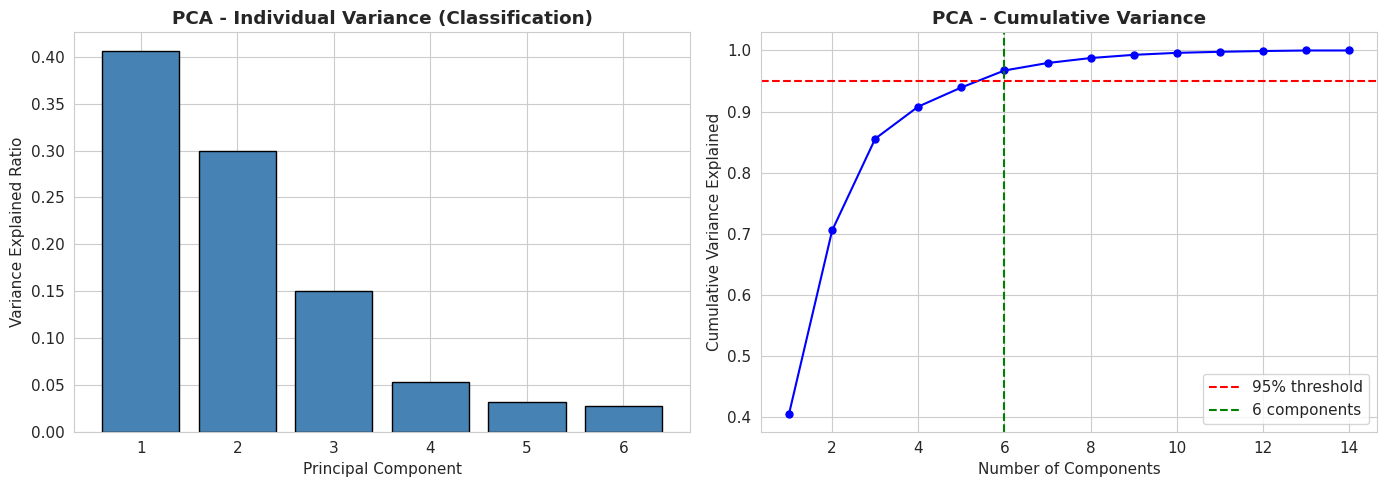

In [23]:
# PCA variance explained plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_cls.explained_variance_ratio_)+1),
            pca_cls.explained_variance_ratio_, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title('PCA - Individual Variance (Classification)', fontweight='bold')

pca_full = PCA().fit(X_cls_std)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'bo-', markersize=5)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(x=X_cls_pca.shape[1], color='green', linestyle='--', label=f'{X_cls_pca.shape[1]} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('PCA - Cumulative Variance', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# Load and preprocess images for CNN feature extraction
IMG_SIZE = (128, 128)

def load_images(base_dir, target_classes, img_size=IMG_SIZE):
    images, labels = [], []
    for sp_folder in sorted(os.listdir(base_dir)):
        sp_path = os.path.join(base_dir, sp_folder)
        if not os.path.isdir(sp_path):
            continue
        class_num = int(sp_folder.split('.')[0].strip())
        if class_num not in target_classes:
            continue
        for img_file in sorted(os.listdir(sp_path)):
            try:
                img = Image.open(os.path.join(sp_path, img_file)).convert('RGB')
                img = img.resize(img_size)
                img_arr = np.array(img) / 255.0
                images.append(img_arr)
                labels.append(class_num)
            except Exception as e:
                print(f"Error: {e}")
    return np.array(images), np.array(labels)

target_classes = sorted(df['Class'].unique())
X_imgs, y_imgs = load_images(RGB_DIR, target_classes)

le_img = LabelEncoder()
y_imgs_enc = le_img.fit_transform(y_imgs)

print(f"Images loaded: {X_imgs.shape}")
print(f"Classes: {len(np.unique(y_imgs_enc))}")

Images loaded: (340, 128, 128, 3)
Classes: 30


In [25]:
# CNN model for feature extraction (PyTorch)
class LeafCNN(nn.Module):
    def __init__(self, num_classes):
        super(LeafCNN, self).__init__()
        # Convolution Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.25)

        # Convolution Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(0.25)

        # Convolution Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout2d(0.25)

        # Fully connected
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.drop1(self.pool1(F.relu(self.conv1(x))))
        x = self.drop2(self.pool2(F.relu(self.conv2(x))))
        x = self.drop3(self.pool3(F.relu(self.conv3(x))))
        x = self.flatten(x)
        x = self.drop_fc(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

    def extract_features(self, x):
        """Extract features from the fc1 layer (256-dim vector)."""
        x = self.drop1(self.pool1(F.relu(self.conv1(x))))
        x = self.drop2(self.pool2(F.relu(self.conv2(x))))
        x = self.drop3(self.pool3(F.relu(self.conv3(x))))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        return x

num_classes = len(np.unique(y_imgs_enc))
cnn_model = LeafCNN(num_classes).to(device)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

LeafCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout2d(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3): Dropout2d(p=0.25, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (drop_fc): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=30, bias=True)
)

Total parameters: 8,489,822


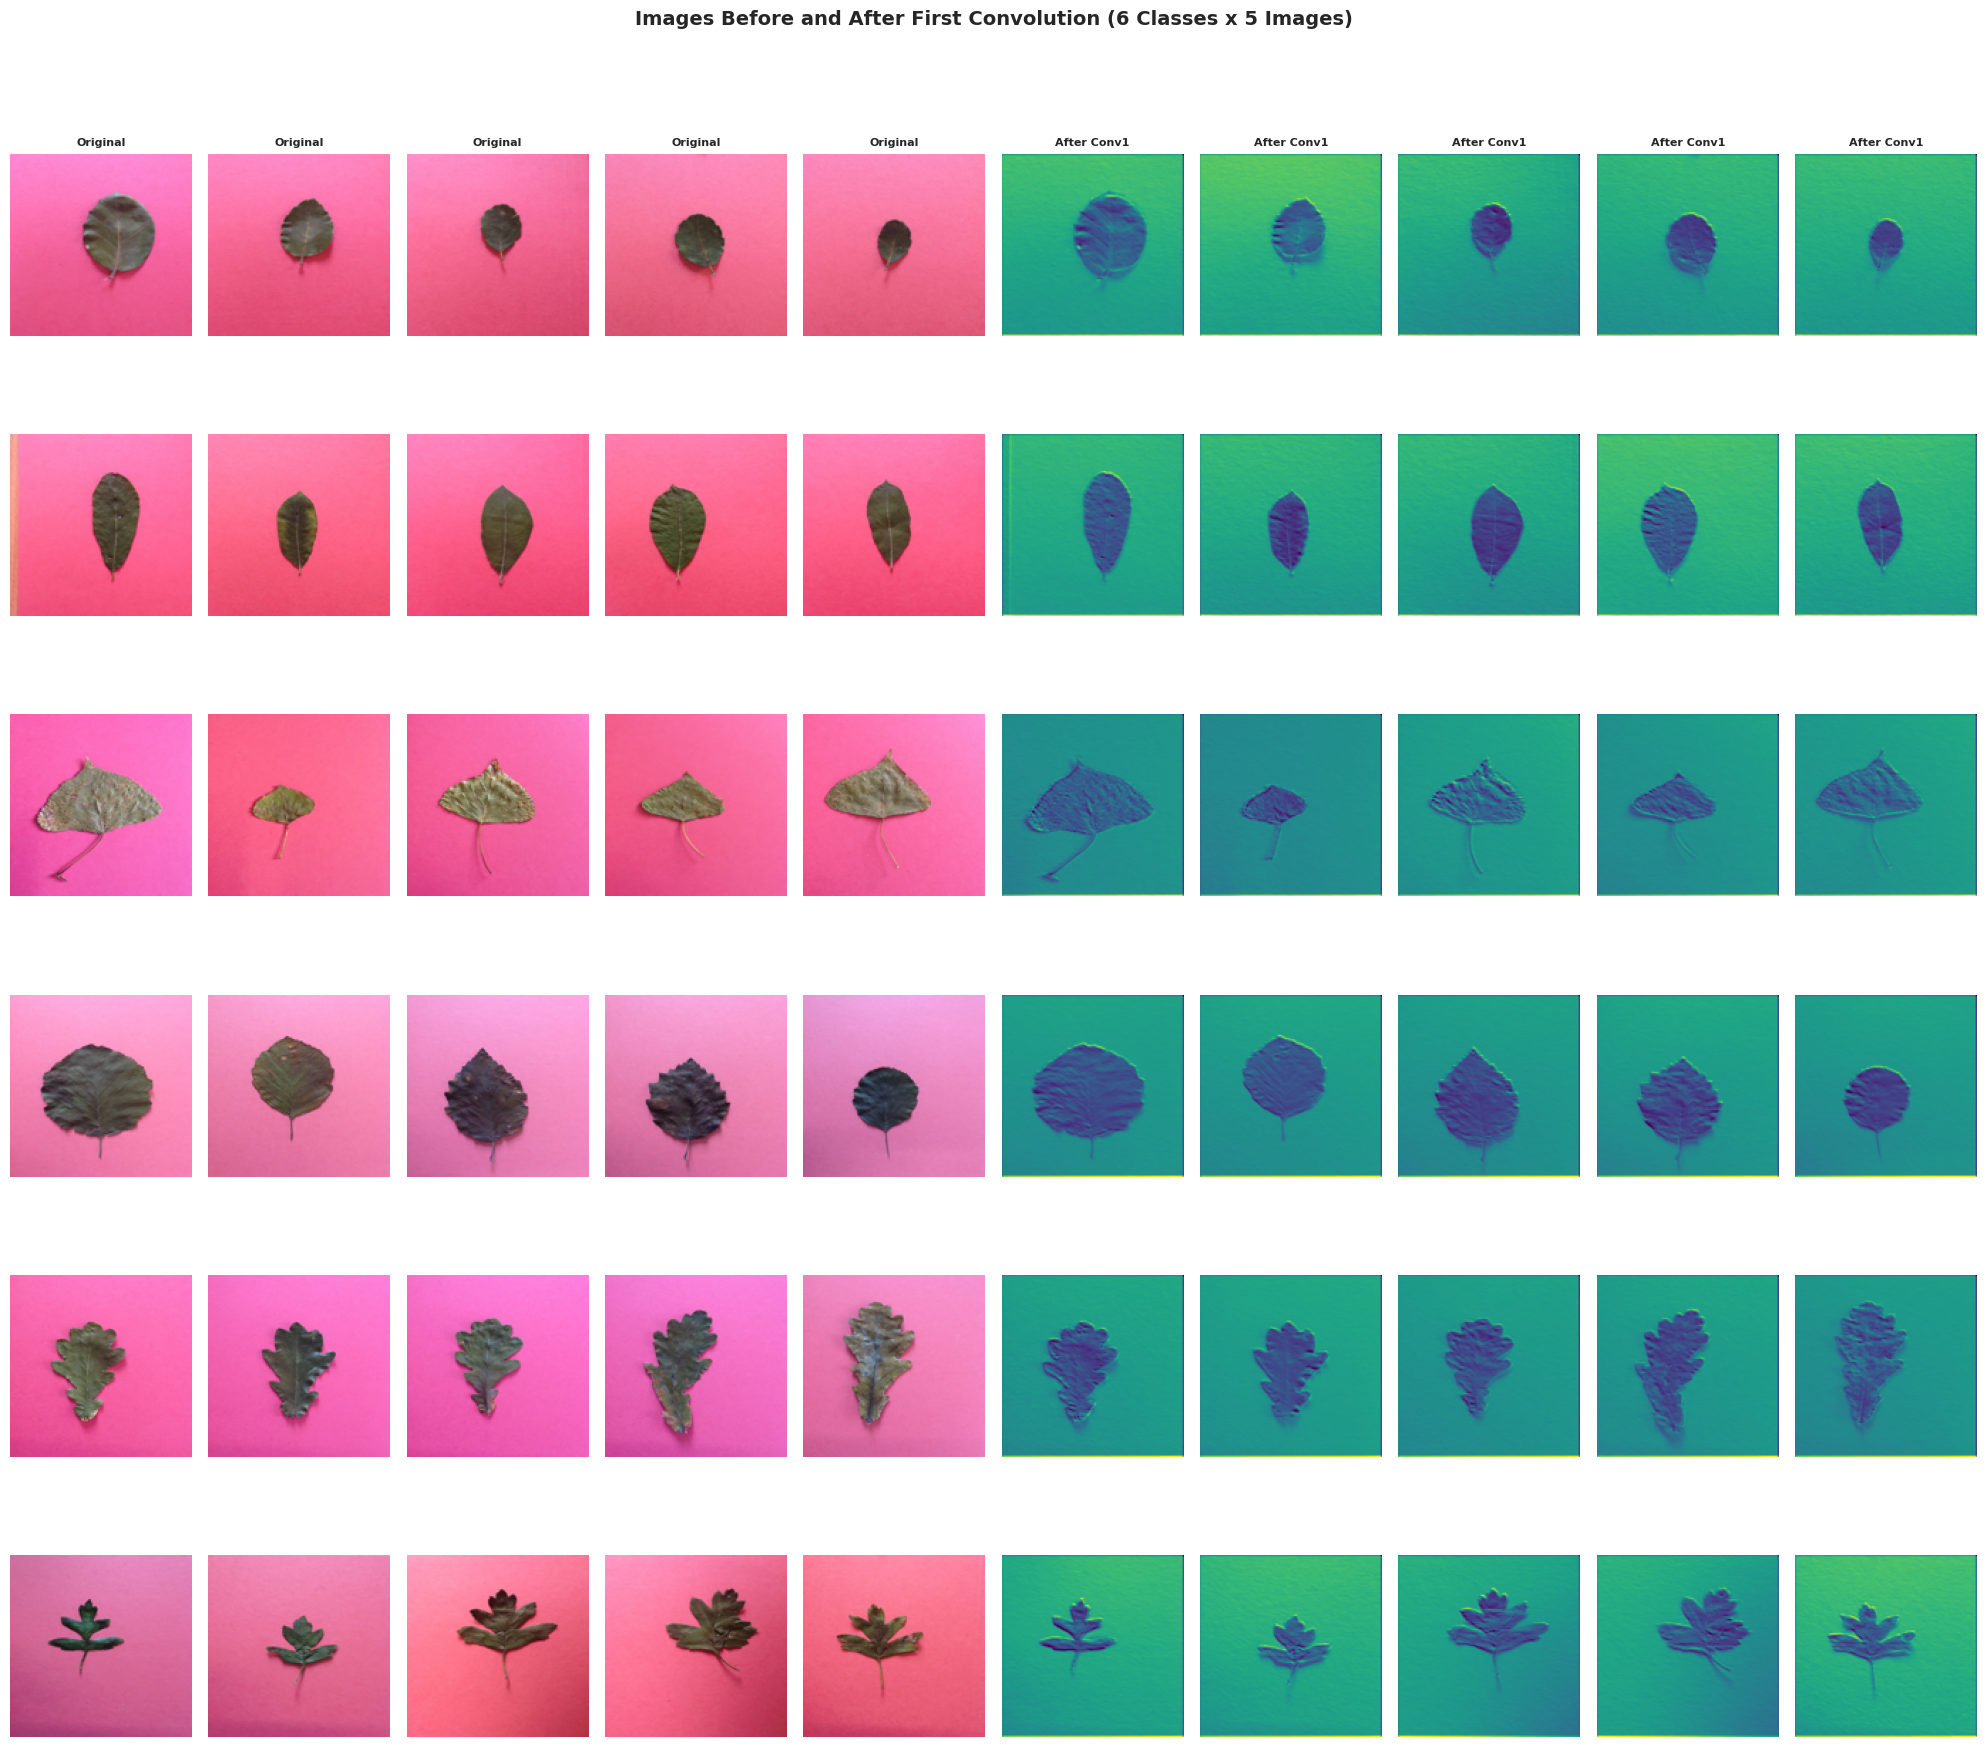

In [26]:
# Plot original images and images after convolution
# First 5 from each of 6 sample classes, one class per row

sample_classes = sorted(df['Class'].unique())[:6]
n_show = 5

# Get conv1 layer output
cnn_model.eval()

fig, axes = plt.subplots(6, n_show * 2, figsize=(20, 18))
fig.suptitle('Images Before and After First Convolution (6 Classes x 5 Images)',
             fontsize=14, fontweight='bold', y=1.01)

# Add column headers
for col_idx in range(n_show):
    axes[0, col_idx].set_title('Original', fontsize=8, fontweight='bold')
    axes[0, col_idx + n_show].set_title('After Conv1', fontsize=8, fontweight='bold')

for row_idx, cls in enumerate(sample_classes):
    cls_mask = y_imgs == cls
    cls_images = X_imgs[cls_mask][:n_show]

    for col_idx in range(min(n_show, len(cls_images))):
        # Original image
        axes[row_idx, col_idx].imshow(cls_images[col_idx])
        axes[row_idx, col_idx].axis('off')

        # After convolution
        img_tensor = torch.FloatTensor(cls_images[col_idx]).permute(2, 0, 1).unsqueeze(0).to(device)
        with torch.no_grad():
            conv_out = F.relu(cnn_model.conv1(img_tensor))
        # Show first feature map
        axes[row_idx, col_idx + n_show].imshow(conv_out[0, 0].cpu().numpy(), cmap='viridis')
        axes[row_idx, col_idx + n_show].axis('off')

    # Row label
    sp_folders = sorted(os.listdir(RGB_DIR))
    cls_name = [s for s in sp_folders if s.startswith(f'{cls}.')][0]
    cls_label = cls_name.split('. ')[1] if '. ' in cls_name else cls_name
    axes[row_idx, 0].set_ylabel(cls_label, fontsize=8, fontweight='bold', rotation=0, labelpad=70)

plt.tight_layout()
plt.show()

In [27]:
# Extract CNN features for all images
cnn_model.eval()

# Convert images to PyTorch tensors (N, C, H, W)
X_imgs_tensor = torch.FloatTensor(X_imgs).permute(0, 3, 1, 2).to(device)

# Extract features in batches
batch_size = 32
all_features = []
with torch.no_grad():
    for i in range(0, len(X_imgs_tensor), batch_size):
        batch = X_imgs_tensor[i:i+batch_size]
        feats = cnn_model.extract_features(batch)
        all_features.append(feats.cpu().numpy())

X_cnn_features = np.vstack(all_features)
print(f"CNN-extracted features: {X_cnn_features.shape}")
print(f"Each image -> {X_cnn_features.shape[1]}-dimensional feature vector")

CNN-extracted features: (340, 256)
Each image -> 256-dimensional feature vector


### 4.1.4 Integrate Data

No external data integration required. The feature dataset and CNN-extracted image features are maintained as separate pipelines with consistent class labels.

### 4.1.5 Format Data

All prepared datasets are split into training and testing sets (80/20 stratified).

In [28]:
# Format and split data for classification
X_tr_orig, X_te_orig, y_tr, y_te = train_test_split(
    X_cls, y_cls_enc, test_size=0.2, random_state=42, stratify=y_cls_enc)
X_tr_norm, X_te_norm = train_test_split(
    X_cls_norm, test_size=0.2, random_state=42, stratify=y_cls_enc)[:2]
X_tr_std, X_te_std = train_test_split(
    X_cls_std, test_size=0.2, random_state=42, stratify=y_cls_enc)[:2]
X_tr_pca, X_te_pca = train_test_split(
    X_cls_pca, test_size=0.2, random_state=42, stratify=y_cls_enc)[:2]
X_tr_lda, X_te_lda = train_test_split(
    X_cls_lda, test_size=0.2, random_state=42, stratify=y_cls_enc)[:2]
X_tr_cnn, X_te_cnn, y_tr_img, y_te_img = train_test_split(
    X_cnn_features, y_imgs_enc, test_size=0.2, random_state=42, stratify=y_imgs_enc)

print("=" * 60)
print("CLASSIFICATION - PREPARED DATASETS")
print("=" * 60)
for name, tr, te in [('Original', X_tr_orig, X_te_orig),
                      ('Normalized', X_tr_norm, X_te_norm),
                      ('Standardized', X_tr_std, X_te_std),
                      ('PCA-reduced', X_tr_pca, X_te_pca),
                      ('LDA-reduced', X_tr_lda, X_te_lda),
                      ('CNN-extracted', X_tr_cnn, X_te_cnn)]:
    print(f"  {name:20s} Train: {str(tr.shape):15s} Test: {str(te.shape)}")
print(f"\nSplit: 80/20 stratified, classes in train: {len(np.unique(y_tr))}")

CLASSIFICATION - PREPARED DATASETS
  Original             Train: (272, 14)       Test: (68, 14)
  Normalized           Train: (272, 14)       Test: (68, 14)
  Standardized         Train: (272, 14)       Test: (68, 14)
  PCA-reduced          Train: (272, 6)        Test: (68, 6)
  LDA-reduced          Train: (272, 14)       Test: (68, 14)
  CNN-extracted        Train: (272, 256)      Test: (68, 256)

Split: 80/20 stratified, classes in train: 30


---
# 5. Clustering (Peng Wang)

## 5.1 Data Preparation

### 5.1.1 Select Data

For clustering (unsupervised), class labels and specimen numbers are removed from the input. True labels are retained separately for evaluation. All 14 features are included; shape-based features may reveal natural groupings while texture features help distinguish species with similar shapes.

In [30]:
# Select data for clustering
X_clu = df[feature_cols].copy()
y_clu_true = df['Class'].copy()

print("Clustering - Selected Data:")
print(f"  Features: {X_clu.shape}")
print(f"  True labels for evaluation: {y_clu_true.nunique()} classes")

Clustering - Selected Data:
  Features: (340, 14)
  True labels for evaluation: 30 classes


### 5.1.2 Clean Data

No additional cleaning required (see Section 3.4).

### 5.1.3 Construct Data

Same five datasets are constructed. Standardization is essential for distance-based clustering (kMeans, DBSCAN).

In [31]:
# Construct 5 datasets for clustering
le_clu = LabelEncoder()
y_clu_enc = le_clu.fit_transform(y_clu_true)

# 1. Original
print("1. Original:", X_clu.shape)

# 2. Normalized
mm_clu = MinMaxScaler()
X_clu_norm = pd.DataFrame(mm_clu.fit_transform(X_clu), columns=feature_cols)
print(f"2. Normalized: {X_clu_norm.shape}")

# 3. Standardized
ss_clu = StandardScaler()
X_clu_std = pd.DataFrame(ss_clu.fit_transform(X_clu), columns=feature_cols)
print(f"3. Standardized: {X_clu_std.shape}")

# 4. PCA-reduced
pca_clu = PCA(n_components=0.95)
X_clu_pca = pca_clu.fit_transform(X_clu_std)
print(f"4. PCA-reduced: {X_clu_pca.shape}, variance: {pca_clu.explained_variance_ratio_.sum():.4f}")

# 5. LDA-reduced
lda_clu = LDA()
X_clu_lda = lda_clu.fit_transform(X_clu_std, y_clu_enc)
print(f"5. LDA-reduced: {X_clu_lda.shape}")

1. Original: (340, 14)
2. Normalized: (340, 14)
3. Standardized: (340, 14)
4. PCA-reduced: (340, 6), variance: 0.9673
5. LDA-reduced: (340, 14)


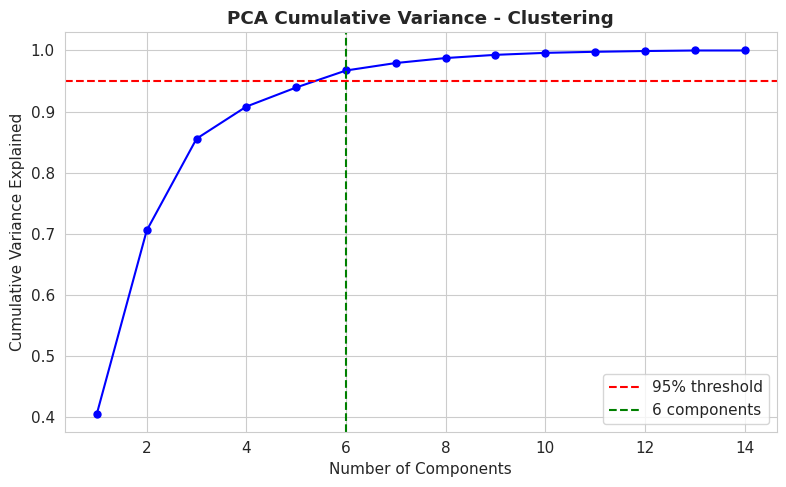

In [32]:
# PCA cumulative variance plot for clustering
fig, ax = plt.subplots(figsize=(8, 5))
pca_full_clu = PCA().fit(X_clu_std)
cumvar_clu = np.cumsum(pca_full_clu.explained_variance_ratio_)
ax.plot(range(1, len(cumvar_clu)+1), cumvar_clu, 'bo-', markersize=5)
ax.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
ax.axvline(x=X_clu_pca.shape[1], color='green', linestyle='--', label=f'{X_clu_pca.shape[1]} components')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('PCA Cumulative Variance - Clustering', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 5.1.4 Integrate Data

No additional integration required.

### 5.1.5 Format Data

Clustering uses the full dataset (no train-test split). True labels are kept for external validation (Adjusted Rand Index, Normalized Mutual Information).

In [33]:
# Summary for clustering
print("=" * 60)
print("CLUSTERING - PREPARED DATASETS")
print("=" * 60)
for name, data in [('Original', X_clu), ('Normalized', X_clu_norm),
                    ('Standardized', X_clu_std), ('PCA-reduced', X_clu_pca),
                    ('LDA-reduced', X_clu_lda), ('CNN-extracted', X_cnn_features)]:
    shape = data.shape if hasattr(data, 'shape') else np.array(data).shape
    print(f"  {name:20s} Shape: {shape}")
print(f"\nNo train-test split (full dataset used).")
print(f"True labels for validation: {y_clu_true.nunique()} classes")

CLUSTERING - PREPARED DATASETS
  Original             Shape: (340, 14)
  Normalized           Shape: (340, 14)
  Standardized         Shape: (340, 14)
  PCA-reduced          Shape: (340, 6)
  LDA-reduced          Shape: (340, 14)
  CNN-extracted        Shape: (340, 256)

No train-test split (full dataset used).
True labels for validation: 30 classes


---
# 6. Outlier Detection (Yinyuan Chen)

## 6.1 Data Preparation

### 6.1.1 Select Data

All 14 features are selected. Class label and specimen number are excluded. Features with high variance or skewness (Lobedness, Max Indentation Depth, Third Moment) are expected to be informative for identifying unusual specimens. Preparation is done independently from clustering.

In [34]:
# Select data for outlier detection
X_out = df[feature_cols].copy()
y_out_true = df['Class'].copy()

print("Outlier Detection - Selected Data:")
print(f"  Features: {X_out.shape}")
print()

# Skewness analysis
skewness = X_out.skew().sort_values(ascending=False)
print("Feature skewness:")
for col, sk in skewness.items():
    flag = " <-- highly skewed" if abs(sk) > 2 else ""
    print(f"  {col}: {sk:.3f}{flag}")

Outlier Detection - Selected Data:
  Features: (340, 14)

Feature skewness:
  Aspect_Ratio: 3.325 <-- highly skewed
  Lobedness: 3.116 <-- highly skewed
  Uniformity: 2.125 <-- highly skewed
  Third_Moment: 1.780
  Max_Indentation_Depth: 1.707
  Smoothness: 1.213
  Avg_Intensity: 0.939
  Entropy: 0.490
  Avg_Contrast: 0.465
  Elongation: 0.338
  Isoperimetric_Factor: -0.477
  Eccentricity: -0.560
  Solidity: -2.061 <-- highly skewed
  Stochastic_Convexity: -2.633 <-- highly skewed


### 6.1.2 Clean Data

No cleaning required. Potential outliers are intentionally kept, as detecting them is the objective.

### 6.1.3 Construct Data

Same five datasets. Standardization is critical for LOF and One-Class SVM (distance-based methods).

In [35]:
# Construct 5 datasets for outlier detection
le_out = LabelEncoder()
y_out_enc = le_out.fit_transform(y_out_true)

print("1. Original:", X_out.shape)

mm_out = MinMaxScaler()
X_out_norm = pd.DataFrame(mm_out.fit_transform(X_out), columns=feature_cols)
print(f"2. Normalized: {X_out_norm.shape}")

ss_out = StandardScaler()
X_out_std = pd.DataFrame(ss_out.fit_transform(X_out), columns=feature_cols)
print(f"3. Standardized: {X_out_std.shape}")

pca_out = PCA(n_components=0.95)
X_out_pca = pca_out.fit_transform(X_out_std)
print(f"4. PCA-reduced: {X_out_pca.shape}, variance: {pca_out.explained_variance_ratio_.sum():.4f}")

lda_out = LDA()
X_out_lda = lda_out.fit_transform(X_out_std, y_out_enc)
print(f"5. LDA-reduced: {X_out_lda.shape}")

1. Original: (340, 14)
2. Normalized: (340, 14)
3. Standardized: (340, 14)
4. PCA-reduced: (340, 6), variance: 0.9673
5. LDA-reduced: (340, 14)


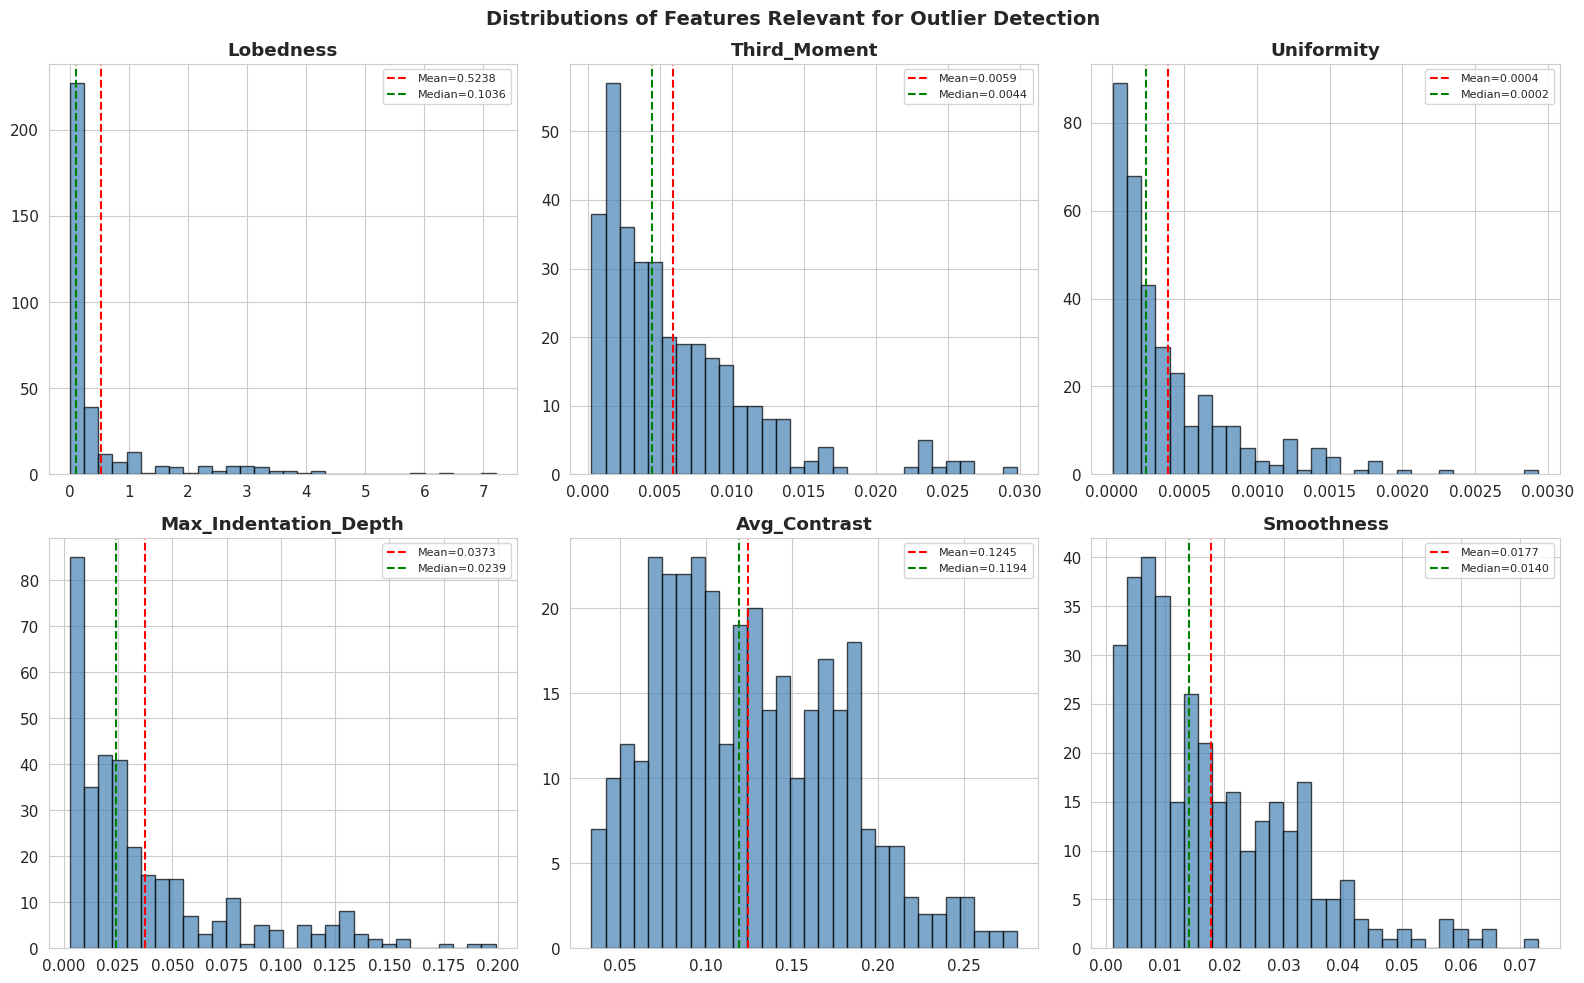

In [36]:
# Distributions of features relevant for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
skewed_feats = ['Lobedness', 'Third_Moment', 'Uniformity',
                'Max_Indentation_Depth', 'Avg_Contrast', 'Smoothness']

for i, col in enumerate(skewed_feats):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.4f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median={df[col].median():.4f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

fig.suptitle('Distributions of Features Relevant for Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.1.4 Integrate Data

No additional integration required.

### 6.1.5 Format Data

Outlier detection uses the full dataset (no train-test split). Each instance is scored as normal or anomalous.

In [37]:
# Summary for outlier detection
print("=" * 60)
print("OUTLIER DETECTION - PREPARED DATASETS")
print("=" * 60)
for name, data in [('Original', X_out), ('Normalized', X_out_norm),
                    ('Standardized', X_out_std), ('PCA-reduced', X_out_pca),
                    ('LDA-reduced', X_out_lda), ('CNN-extracted', X_cnn_features)]:
    shape = data.shape if hasattr(data, 'shape') else np.array(data).shape
    print(f"  {name:20s} Shape: {shape}")
print(f"\nNo train-test split (full dataset used).")
print(f"Results will be compared across LOF, Isolation Forest, and One-Class SVM.")

OUTLIER DETECTION - PREPARED DATASETS
  Original             Shape: (340, 14)
  Normalized           Shape: (340, 14)
  Standardized         Shape: (340, 14)
  PCA-reduced          Shape: (340, 6)
  LDA-reduced          Shape: (340, 14)
  CNN-extracted        Shape: (340, 256)

No train-test split (full dataset used).
Results will be compared across LOF, Isolation Forest, and One-Class SVM.


---
# Summary (Peng Wang)

Part 1 of the project is complete:

1. **Business Understanding** – Defined objectives, assessed the situation, set data mining goals, and produced a project plan with workload distribution.

2. **Data Understanding** – Collected and described the feature dataset (340 instances, 14 features, 30 species) and image dataset (RGB: 443 images/40 species, BW: 340 images/30 species). Conducted exploratory analysis with all visualizations. Verified data quality.

3. **Data Preparation** – Each member prepared data for their task:
   - **Classification (Peng Wang):** 5 dataset versions + CNN features, 80/20 stratified splits.\n",
    "   - **Clustering (Hye Ran Yoo):** 5 dataset versions + CNN features, full dataset.
   - **Outlier Detection (Yinyuan Chen):** 5 dataset versions + CNN features, full dataset.

All datasets are ready for modelling in Part 2.